<a href="https://colab.research.google.com/github/cksleigen/lg-aimers-demand-forecasting/blob/chanhee/XGBOOST_0811.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 로드

In [ ]:
!pip install --upgrade xgboost==1.7.6

# i) optuna & XGBOOST
* submission.csv 형식 안 맞춰져있음

In [ ]:
# -*- coding: utf-8 -*-
"""
Colab XGB Two‑Stage Forecast with Optuna Hyperparameter Tuning
- 목적: 리조트 내 식음업장 '매장_메뉴'별 7일 예측 (제로‑인플레이션 대응)
- 접근: 1단계 분류(y>0?) + 2단계 회귀(y|y>0) + Optuna 하이퍼파라미터 튜닝
- 특징: 시계열 홀드아웃(누수 방지) & 순차 예측

사용법(Colab):
1) GPU 런타임 권장. 아래 pip 설치/드라이브 마운트 블록 먼저 실행
2) PATH 부분을 내 환경에 맞게 수정
3) 전체 스크립트를 순서대로 실행 → 최적화된 모델로 submission.csv 생성
"""

# =============================
# 설치 & 마운트 (Colab 전용)
# =============================
try:
    import xgboost as xgb  # noqa: F401
except Exception:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost==2.1.1'])

try:
    import optuna  # noqa: F401
except Exception:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except Exception:
    pass  # Colab이 아닐 수도 있음

# =============================
# imports
# =============================
import os, re, gc, glob, warnings
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict, Any
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings("ignore")
pd.options.display.float_format = lambda x: f"{x:,.4f}"

# =============================
# Optuna 설정
# =============================
OPTUNA_N_TRIALS = 100  # 시행 횟수 (시간에 따라 조정)
OPTUNA_TIMEOUT = 3600  # 1시간 제한 (초 단위)
OPTUNA_N_JOBS = 1      # 병렬 처리 수
EARLY_STOPPING_ROUNDS = 50  # XGBoost early stopping

# --- Holidays (provided by user) ---
HOLIDAYS = [
    pd.to_datetime("2023-01-01").date(),
    pd.to_datetime("2023-01-21").date(),
    pd.to_datetime("2023-01-22").date(),
    pd.to_datetime("2023-01-23").date(),
    pd.to_datetime("2023-01-24").date(),
    pd.to_datetime("2023-03-01").date(),
    pd.to_datetime("2023-05-01").date(),
    pd.to_datetime("2023-05-05").date(),
    pd.to_datetime("2023-05-27").date(),
    pd.to_datetime("2023-05-29").date(),
    pd.to_datetime("2023-06-06").date(),
    pd.to_datetime("2023-08-15").date(),
    pd.to_datetime("2023-09-28").date(),
    pd.to_datetime("2023-09-29").date(),
    pd.to_datetime("2023-09-30").date(),
    pd.to_datetime("2023-10-02").date(),
    pd.to_datetime("2023-10-03").date(),
    pd.to_datetime("2023-10-09").date(),
    pd.to_datetime("2023-12-25").date(),
    pd.to_datetime("2024-01-01").date(),
    pd.to_datetime("2024-02-09").date(),
    pd.to_datetime("2024-02-10").date(),
    pd.to_datetime("2024-02-11").date(),
    pd.to_datetime("2024-02-12").date(),
    pd.to_datetime("2024-03-01").date(),
    pd.to_datetime("2024-04-10").date(),
    pd.to_datetime("2024-05-01").date(),
    pd.to_datetime("2024-05-05").date(),
    pd.to_datetime("2024-05-06").date(),
    pd.to_datetime("2024-05-15").date(),
    pd.to_datetime("2024-06-06").date(),
    pd.to_datetime("2024-08-15").date(),
    pd.to_datetime("2024-09-16").date(),
    pd.to_datetime("2024-09-17").date(),
    pd.to_datetime("2024-09-18").date(),
    pd.to_datetime("2024-10-01").date(),
    pd.to_datetime("2024-10-03").date(),
    pd.to_datetime("2024-10-09").date(),
    pd.to_datetime("2024-12-25").date(),
    pd.to_datetime("2025-01-01").date(),
    pd.to_datetime("2025-01-28").date(),
    pd.to_datetime("2025-01-29").date(),
    pd.to_datetime("2025-01-30").date(),
    pd.to_datetime("2025-03-01").date(),
    pd.to_datetime("2025-03-03").date(),
    pd.to_datetime("2025-05-01").date(),
    pd.to_datetime("2025-05-05").date(),
    pd.to_datetime("2025-05-06").date(),
    pd.to_datetime("2025-06-06").date(),
    pd.to_datetime("2025-08-15").date(),
]
HOLIDAY_SET = set(HOLIDAYS)

# =============================
# 경로 설정 (필요시 수정)
# =============================
DATA_ROOT = "/content/drive/MyDrive/data"  # <- 본인 경로
TRAIN_PATH = os.path.join(DATA_ROOT, "train", "preprocessed_train_onehot_True.csv")
TEST_DIR   = os.path.join(DATA_ROOT, "test")  # 내부에 TEST_00..TEST_09.csv
SAMPLE_SUBMISSION_PATH = os.path.join(DATA_ROOT, "sample_submission.csv")
OUTPUT_PATH = "/content/drive/MyDrive/output/xgb_optuna_submission.csv"
OPTUNA_DB_PATH = "/content/drive/MyDrive/output/optuna_study.db"
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# =============================
# 유틸리티 함수들 (이전 코드와 동일)
# =============================
K_DATE_COLS = ["영업일자", "date", "날짜", "일자"]
K_ITEM_COLS = ["영업장명_메뉴명", "매장_메뉴", "store_menu", "상품", "품목", "메뉴"]
K_QTY_COLS  = ["매출수량", "수량", "판매수량", "qty", "quantity"]

def read_csv_any(path: str) -> pd.DataFrame:
    last = None
    for enc in ["utf-8", "cp949", "euc-kr", "utf-8-sig"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last = e
    raise RuntimeError(f"CSV read failed for {path}: {last}")

@dataclass
class Columns:
    date: str
    item: str
    qty: str

def detect_columns(df: pd.DataFrame) -> Columns:
    """컬럼 탐지 함수 - sample_submission 형식도 처리"""
    date_col = next((c for c in df.columns if c in K_DATE_COLS), None)
    item_col = next((c for c in df.columns if c in K_ITEM_COLS), None)
    qty_col  = next((c for c in df.columns if c in K_QTY_COLS), None)

    if not (date_col and item_col and qty_col):
        # heuristic
        for c in df.columns:
            cs = str(c)
            if (not date_col) and ("영업" in cs and "일자" in cs):
                date_col = c
            if (not item_col) and (("영업장" in cs and "메뉴" in cs) or ("메뉴" in cs and "_" in cs)):
                item_col = c
            if (not qty_col) and (("매출" in cs and "수량" in cs) or ("판매" in cs and "수량" in cs)):
                qty_col = c

    # sample_submission의 경우 다른 형식일 수 있음
    if not qty_col:
        cols = df.columns.tolist()
        if len(cols) > 1 and any("_" in str(col) for col in cols[1:]):
            return Columns(date=cols[0], item="pivot_format", qty="pivot_format")

    if not (date_col and item_col and qty_col):
        print(f"Available columns: {df.columns.tolist()}")
        raise ValueError(f"Cannot detect required columns in dataframe")

    return Columns(date=date_col, item=item_col, qty=qty_col)

def season_from_month(m: int) -> str:
    if m in [3,4,5]: return "봄"
    if m in [6,7,8]: return "여름"
    if m in [9,10,11]: return "가을"
    return "겨울"

def split_store_menu(s: pd.Series) -> Tuple[pd.Series, pd.Series]:
    sp = s.astype(str).str.split("_", n=1, expand=True)
    if isinstance(sp, pd.DataFrame) and sp.shape[1] == 2:
        return sp[0], sp[1]
    return s, pd.Series([""] * len(s), index=s.index)

def parse_train_onehot_format(train_df: pd.DataFrame) -> pd.DataFrame:
    """원핫인코딩된 train 데이터를 long format으로 변환"""
    result_rows = []

    # 영업일자 컬럼 찾기
    date_col = None
    for col in train_df.columns:
        if '영업일자' in str(col):
            date_col = col
            break

    if date_col is None:
        raise ValueError("영업일자 컬럼을 찾을 수 없습니다")

    # 매출수량 컬럼 찾기
    qty_col = None
    for col in train_df.columns:
        if '매출수량' in str(col):
            qty_col = col
            break

    if qty_col is None:
        raise ValueError("매출수량 컬럼을 찾을 수 없습니다")

    # 각 행을 처리
    for idx, row in train_df.iterrows():
        date_val = row[date_col]
        qty_val = row[qty_col]

        # 영업장명 찾기
        store_name = None
        for col in train_df.columns:
            if '영업장명_' in str(col) and row[col] == 1:
                store_name = str(col).replace('영업장명_', '')
                break

        # 메뉴명 찾기
        menu_name = None
        for col in train_df.columns:
            if '메뉴명_' in str(col) and row[col] == 1:
                menu_name = str(col).replace('메뉴명_', '')
                break

        if store_name and menu_name:
            result_rows.append({
                '영업일자': date_val,
                '영업장명_메뉴명': f"{store_name}_{menu_name}",
                '매출수량': qty_val,
                'store': store_name,
                'menu': menu_name
            })

    return pd.DataFrame(result_rows)

# =============================
# 데이터 적재 및 전처리 (이전 코드와 유사)
# =============================
print("[LOAD] train/test")
train_raw = read_csv_any(TRAIN_PATH)

# train 데이터가 원핫인코딩 형식인지 확인하고 변환
if '영업장명_' in str(train_raw.columns).replace("'", ""):
    print("[INFO] Converting one-hot encoded train data to long format...")
    train = parse_train_onehot_format(train_raw)
    cols = Columns(date='영업일자', item='영업장명_메뉴명', qty='매출수량')
else:
    train = train_raw
    cols = detect_columns(train)

def load_test_frames(test_dir: str) -> pd.DataFrame:
    paths = sorted(glob.glob(os.path.join(test_dir, "TEST_*.csv")))
    if not paths:
        raise FileNotFoundError(f"No TEST_*.csv in {test_dir}")
    li = [read_csv_any(p) for p in paths]
    for i in range(len(li)):
        c = detect_columns(li[i])
        if c.item != "pivot_format":
            li[i] = li[i].rename(columns={c.date: cols.date, c.item: cols.item, c.qty: cols.qty})
    df = pd.concat(li, ignore_index=True)
    return df

try:
    test = load_test_frames(TEST_DIR)
except Exception as e:
    print("[WARN] test load failed:", e)
    test = None

# 전처리
for df in [train] + ([test] if test is not None else []):
    df["date"] = pd.to_datetime(df[cols.date].astype(str).str.replace(".", "-", regex=False), errors="coerce")
    df["qty"] = pd.to_numeric(df[cols.qty], errors="coerce").fillna(0)
    df.loc[df["qty"] < 0, "qty"] = 0
    if 'store' not in df.columns or 'menu' not in df.columns:
        df["store"], df["menu"] = split_store_menu(df[cols.item])
    df["store"] = df["store"].astype(str)
    df["menu"]  = df["menu"].astype(str)

# NaT 제거 및 정렬
train = train.dropna(subset=["date"]).sort_values(["store", "menu", "date"]).reset_index(drop=True)
if test is not None:
    test = test.dropna(subset=["date"]).sort_values(["store", "menu", "date"]).reset_index(drop=True)

# 캘린더/공휴일
for df in [train] + ([test] if test is not None else []):
    df["dow"] = df["date"].dt.weekday
    df["is_weekend"] = df["dow"].isin([5,6]).astype(int)
    df["month"] = df["date"].dt.month
    df["iso_week"] = df["date"].dt.isocalendar().week.astype(int)
    df["season"] = df["month"].apply(season_from_month)
    df["is_holiday"] = df["date"].dt.date.isin(HOLIDAY_SET).astype(int)

# 타깃 인코딩
train['store'] = train['store'].astype(str)
train['menu']  = train['menu'].astype(str)

store_mean = train.groupby('store')['qty'].mean().rename('te_store')
menu_mean  = train.groupby('menu')['qty'].mean().rename('te_menu')
sm_mean    = train.groupby(['store','menu'])['qty'].mean().rename('te_store_menu')

def apply_target_encoding(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['store'] = out['store'].astype(str)
    out['menu']  = out['menu'].astype(str)
    out = out.join(store_mean, on='store')
    out = out.join(menu_mean, on='menu')
    out = out.join(sm_mean, on=['store','menu'])
    return out

train = apply_target_encoding(train)
if test is not None:
    test = apply_target_encoding(test)

# NA 채우기
for col in ['te_store', 'te_menu', 'te_store_menu']:
    global_mean = train['qty'].mean()
    train[col] = train[col].fillna(global_mean)
    if test is not None:
        test[col] = test[col].fillna(global_mean)

# 랙/롤링 생성
LAGS = [1,2,3,7,14,28]
RWS  = [7,14,28]
KEY = ['store','menu']

def add_lag_roll_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(KEY + ['date']).copy()
    for lag in LAGS:
        df[f'lag_{lag}'] = df.groupby(KEY, observed=True)['qty'].shift(lag)
    for w in RWS:
        g = df.groupby(KEY, observed=True)['qty']
        df[f'rmean_{w}'] = g.shift(1).rolling(w, min_periods=max(1, w//3)).mean()
        df[f'rstd_{w}']  = g.shift(1).rolling(w, min_periods=max(1, w//3)).std()
        df[f'rmax_{w}']  = g.shift(1).rolling(w, min_periods=max(1, w//3)).max()
    return df

train = add_lag_roll_features(train)

# 초기 학습 가능 구간 필터
MIN_PAST = 7
mask_train = ~train[[f'lag_{l}' for l in LAGS]].isna().any(axis=1)
train_fit = train[mask_train].reset_index(drop=True)

# 피처 구성
CAL_FEATS = ['dow','is_weekend','month','iso_week','is_holiday']
TE_FEATS  = ['te_store','te_menu','te_store_menu']
LAG_FEATS = [f'lag_{l}' for l in LAGS]
ROL_FEATS = [f'rmean_{w}' for w in RWS] + [f'rstd_{w}' for w in RWS] + [f'rmax_{w}' for w in RWS]
BASIC_FEATS = CAL_FEATS + TE_FEATS + LAG_FEATS + ROL_FEATS

# 결측치 처리
train_fit[BASIC_FEATS] = train_fit[BASIC_FEATS].fillna(0)

# 홀드아웃(시간기반)
VAL_DAYS = 21
cutoff = train['date'].max() - pd.Timedelta(days=VAL_DAYS)
train_idx = train_fit['date'] <= cutoff
valid_idx = train_fit['date'] >  cutoff

X_tr, X_va = train_fit.loc[train_idx, BASIC_FEATS], train_fit.loc[valid_idx, BASIC_FEATS]
y_tr, y_va = train_fit.loc[train_idx, 'qty'],        train_fit.loc[valid_idx, 'qty']

# 1단계 분류 타깃
y_tr_cls = (y_tr > 0).astype(int)
y_va_cls = (y_va > 0).astype(int)

# 2단계 회귀 타깃(양수만)
pos_tr = y_tr > 0
pos_va = y_va > 0

# =============================
# Optuna 목적 함수 정의
# =============================
def smape(a, f, eps=1e-9):
    a = np.asarray(a, dtype=float)
    f = np.asarray(f, dtype=float)
    denom = (np.abs(a) + np.abs(f)) + eps
    return np.mean(2.0 * np.abs(f - a) / denom)

def objective(trial):
    """Optuna 목적 함수: two-stage 모델의 하이퍼파라미터 최적화"""

    # GPU 설정
    USE_GPU = os.environ.get('COLAB_GPU', '0') != '0' or os.path.exists('/usr/local/cuda')
    DEVICE = 'cuda' if USE_GPU else 'cpu'

    # 1단계 분류기 하이퍼파라미터
    clf_params = {
        'n_estimators': trial.suggest_int('clf_n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('clf_max_depth', 4, 12),
        'learning_rate': trial.suggest_float('clf_learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('clf_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('clf_colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('clf_reg_lambda', 0.1, 10.0, log=True),
        'reg_alpha': trial.suggest_float('clf_reg_alpha', 0.0, 1.0),
        'min_child_weight': trial.suggest_int('clf_min_child_weight', 1, 10),
        'objective': 'binary:logistic',
        'tree_method': 'hist',
        'device': DEVICE,
        'eval_metric': 'logloss',
        'n_jobs': 0,
        'random_state': 42,
    }

    # 2단계 회귀기 하이퍼파라미터
    reg_params = {
        'n_estimators': trial.suggest_int('reg_n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('reg_max_depth', 4, 12),
        'learning_rate': trial.suggest_float('reg_learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('reg_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('reg_colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'min_child_weight': trial.suggest_int('reg_min_child_weight', 1, 10),
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': DEVICE,
        'n_jobs': 0,
        'random_state': 42,
    }

    # 임계값 최적화
    threshold = trial.suggest_float('threshold', 0.3, 0.7)

    try:
        # 1단계: 분류기 학습
        clf = xgb.XGBClassifier(**clf_params)
        clf.fit(
            X_tr, y_tr_cls,
            eval_set=[(X_va, y_va_cls)],
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose=False,
        )

        # 2단계: 회귀기 학습 (양수인 경우만)
        if pos_tr.sum() > 10:  # 최소 데이터 확보
            reg = xgb.XGBRegressor(**reg_params)
            reg.fit(
                X_tr.loc[pos_tr], np.log1p(y_tr[pos_tr]),
                eval_set=[(X_va.loc[pos_va], np.log1p(y_va[pos_va]))],
                early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                verbose=False,
            )

            # 검증 예측
            va_proba = clf.predict_proba(X_va)[:,1]
            va_pos_pred = np.expm1(reg.predict(X_va))
            va_pred = (va_proba >= threshold).astype(int) * np.clip(va_pos_pred, 0, None)
        else:
            # 회귀 데이터가 너무 적은 경우 분류만 사용
            va_proba = clf.predict_proba(X_va)[:,1]
            va_pred = (va_proba >= threshold).astype(int) * y_tr.mean()

        # sMAPE 계산 (목적함수)
        score = smape(y_va.values, va_pred)

        # 추가 지표들도 기록 (분석용)
        mae = np.mean(np.abs(va_pred - y_va.values))
        trial.set_user_attr('mae', mae)
        trial.set_user_attr('positive_rate', y_va_cls.mean())

        return score

    except Exception as e:
        print(f"Trial failed: {e}")
        return float('inf')  # 실패한 경우 최악의 점수

# =============================
# Optuna 최적화 실행
# =============================
print(f"[OPTUNA] Starting hyperparameter optimization with {OPTUNA_N_TRIALS} trials...")

# Study 생성 (DB에 저장하여 중간 결과 보존)
study = optuna.create_study(
    direction='minimize',  # sMAPE를 최소화
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    study_name='xgb_two_stage_optimization',
    storage=f'sqlite:///{OPTUNA_DB_PATH}',
    load_if_exists=True,
)

# 최적화 실행
study.optimize(
    objective,
    n_trials=OPTUNA_N_TRIALS,
    timeout=OPTUNA_TIMEOUT,
    n_jobs=OPTUNA_N_JOBS,
    show_progress_bar=True,
)

# 최적 결과 출력
print(f"\n[OPTUNA] Best trial:")
print(f"sMAPE: {study.best_value:.4f}")
print(f"Parameters: {study.best_params}")

# 최적 파라미터로 최종 모델 학습
print(f"\n[FINAL] Training final model with best parameters...")

best_params = study.best_params
USE_GPU = os.environ.get('COLAB_GPU', '0') != '0' or os.path.exists('/usr/local/cuda')
DEVICE = 'cuda' if USE_GPU else 'cpu'

# 최적 분류기
best_clf_params = {k.replace('clf_', ''): v for k, v in best_params.items() if k.startswith('clf_')}
best_clf_params.update({
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'device': DEVICE,
    'eval_metric': 'logloss',
    'n_jobs': 0,
    'random_state': 42,
})

# 최적 회귀기
best_reg_params = {k.replace('reg_', ''): v for k, v in best_params.items() if k.startswith('reg_')}
best_reg_params.update({
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'device': DEVICE,
    'n_jobs': 0,
    'random_state': 42,
})

best_threshold = best_params['threshold']

# 최종 모델 학습
final_clf = xgb.XGBClassifier(**best_clf_params)
final_clf.fit(X_tr, y_tr_cls, eval_set=[(X_va, y_va_cls)], verbose=False)

final_reg = xgb.XGBRegressor(**best_reg_params)
final_reg.fit(X_tr.loc[pos_tr], np.log1p(y_tr[pos_tr]),
             eval_set=[(X_va.loc[pos_va], np.log1p(y_va[pos_va]))], verbose=False)

# 최종 검증 성능
va_proba = final_clf.predict_proba(X_va)[:,1]
va_pos_pred = np.expm1(final_reg.predict(X_va))
va_pred = (va_proba >= best_threshold).astype(int) * np.clip(va_pos_pred, 0, None)

final_mae = np.mean(np.abs(va_pred - y_va.values))
final_smape = smape(y_va.values, va_pred)
print(f"[FINAL] Optimized MAE={final_mae:,.3f}, sMAPE={final_smape:.4f}")
print(f"[FINAL] Threshold={best_threshold:.3f}")

# =============================
# 테스트 예측 (최적화된 모델 사용)
# =============================
if test is not None:
    print("[PRED] Running optimized iterative forecasting...")

    # 예측용 베이스 프레임
    test_work = test.copy()

    # train의 마지막 값들을 lag 시드로 사용하기 위해 train+test 결합
    base = train[['date','store','menu','qty']].copy()
    base['kind'] = 'train'
    tt = test_work[['date','store','menu']].copy()
    tt['qty'] = np.nan
    tt['kind'] = 'test'
    all_df = pd.concat([base, tt], ignore_index=True)

    # enforce string dtype to match training encodings
    all_df['store'] = all_df['store'].astype(str)
    all_df['menu']  = all_df['menu'].astype(str)
    all_df = all_df.sort_values(['store','menu','date']).reset_index(drop=True)

    # 타깃 인코딩/캘린더 다시 부여
    all_df = all_df.join(store_mean, on='store')
    all_df = all_df.join(menu_mean,  on='menu')
    all_df = all_df.join(sm_mean,    on=['store','menu'])
    for col in ['te_store','te_menu','te_store_menu']:
        all_df[col] = all_df[col].fillna(train['qty'].mean())

    all_df['dow'] = all_df['date'].dt.weekday
    all_df['is_weekend'] = all_df['dow'].isin([5,6]).astype(int)
    all_df['month'] = all_df['date'].dt.month
    all_df['iso_week'] = all_df['date'].dt.isocalendar().week.astype(int)
    all_df['is_holiday'] = all_df['date'].dt.date.isin(HOLIDAY_SET).astype(int)

    # 예측 결과를 채워갈 열
    all_df['qty_filled'] = all_df['qty']

    # 순차 예측: 테스트 날짜 오름차순으로 한 날씩
    test_dates = sorted(test_work['date'].unique())
    preds = []

    for d in tqdm(test_dates, desc="Forecasting"):
        # 현재 날짜까지 lag/rolling 생성 (qty_filled 사용)
        snap = all_df[all_df['date'] <= d].copy()
        snap = snap.sort_values(['store','menu','date'])

        # lag/rolling 재계산
        for lag in LAGS:
            snap[f'lag_{lag}'] = snap.groupby(KEY, observed=True)['qty_filled'].shift(lag)
        for w in RWS:
            g = snap.groupby(KEY, observed=True)['qty_filled']
            snap[f'rmean_{w}'] = g.shift(1).rolling(w, min_periods=max(1, w//3)).mean()
            snap[f'rstd_{w}']  = g.shift(1).rolling(w, min_periods=max(1, w//3)).std()
            snap[f'rmax_{w}']  = g.shift(1).rolling(w, min_periods=max(1, w//3)).max()

        # 오늘 d의 test 행만 추출해 예측
        today_rows = (snap['date'] == d) & (snap['kind'] == 'test')
        X_today = snap.loc[today_rows, BASIC_FEATS].fillna(0)
        if len(X_today) == 0:
            continue

        # 최적화된 모델로 예측
        p = final_clf.predict_proba(X_today)[:,1]
        r = np.expm1(final_reg.predict(X_today))
        yhat = (p >= best_threshold).astype(int) * np.clip(r, 0, None)

        # 결과 저장 및 qty_filled에 반영 (다음 날 lag로 사용)
        out = snap.loc[today_rows, ['date','store','menu']].copy()
        out['pred'] = yhat
        preds.append(out)

        # all_df에 merge 업데이트
        idx = (all_df['date'] == d)
        idx = idx & (all_df['store'].isin(out['store'])) & (all_df['menu'].isin(out['menu']))
        # 안전하게 키 머지로 업데이트
        upd = out.set_index(['date','store','menu'])['pred']
        all_df.set_index(['date','store','menu'], inplace=True)
        all_df.loc[upd.index, 'qty_filled'] = upd.values
        all_df.reset_index(inplace=True)

    pred_df = pd.concat(preds, ignore_index=True)

    # =============================
    # 제출 형식 맞추기
    # =============================
    def create_submission_file(pred_df: pd.DataFrame, sample_path: str, output_path: str):
        """예측 결과를 sample_submission 형식에 맞춰 저장"""
        try:
            ss = read_csv_any(sample_path)
            print(f"[INFO] Sample submission shape: {ss.shape}")
            print(f"[INFO] Sample submission columns: {ss.columns.tolist()[:5]}...")

            # sample_submission 형식 확인
            if len(ss.columns) > 10:  # 피벗 테이블 형식인 경우
                print("[INFO] Detected pivot table format for sample_submission")

                # 첫 번째 컬럼이 날짜인지 확인
                date_col = ss.columns[0]
                pred_df['store_menu'] = pred_df['store'] + '_' + pred_df['menu']

                # 날짜별로 예측 결과 정리
                pivot_pred = pred_df.pivot_table(
                    index='date',
                    columns='store_menu',
                    values='pred',
                    fill_value=0
                ).reset_index()

                # sample_submission과 동일한 컬럼 순서로 맞추기
                result = ss.copy()

                # 날짜 컬럼 처리
                result[date_col] = pivot_pred['date'].dt.strftime('%Y.%m.%d')

                # 각 매장_메뉴 컬럼에 예측값 채우기
                for col in ss.columns[1:]:  # 첫 번째 컬럼(날짜) 제외
                    if col in pivot_pred.columns:
                        # sample_submission의 해당 날짜와 매치되는 예측값 찾기
                        for idx, row in result.iterrows():
                            date_val = pd.to_datetime(row[date_col].replace('.', '-'))
                            if date_val in pivot_pred['date'].values:
                                pred_idx = pivot_pred[pivot_pred['date'] == date_val].index
                                if len(pred_idx) > 0:
                                    result.loc[idx, col] = pivot_pred.loc[pred_idx[0], col]

                result.to_csv(output_path, index=False, encoding='utf-8-sig')
                print(f"[SUCCESS] Optimized pivot format submission saved to {output_path}")

            else:  # 일반 long format인 경우
                print("[INFO] Detected long format for sample_submission")
                ss_cols = detect_columns(ss)
                ss['date'] = pd.to_datetime(ss[ss_cols.date].astype(str).str.replace('.', '-', regex=False), errors='coerce')
                ss['store'], ss['menu'] = split_store_menu(ss[ss_cols.item])
                ss['store'] = ss['store'].astype(str)
                ss['menu'] = ss['menu'].astype(str)

                # 병합하여 sample의 순서/형식 유지
                merged = ss[['date','store','menu']].merge(pred_df, on=['date','store','menu'], how='left')
                out = ss[[ss_cols.date, ss_cols.item]].copy()
                out[ss_cols.qty] = np.clip(merged['pred'].fillna(0).values, 0, None)
                out.to_csv(output_path, index=False, encoding='utf-8-sig')
                print(f"[SUCCESS] Optimized long format submission saved to {output_path}")

        except Exception as e:
            print(f"[ERROR] Failed to process sample_submission: {e}")
            print("[INFO] Creating submission without sample format...")

            # fallback: 직접 생성
            sub = test_work[['date','store','menu']].copy()
            sub['store_menu'] = sub['store'] + '_' + sub['menu']
            sub = sub.merge(pred_df[['date','store','menu','pred']], on=['date','store','menu'], how='left')
            sub['pred'] = np.clip(sub['pred'].fillna(0), 0, None)

            # 간단한 형식으로 저장
            result = sub[['date', 'store_menu', 'pred']].copy()
            result.columns = ['영업일자', '영업장명_메뉴명', '매출수량']
            result['영업일자'] = result['영업일자'].dt.strftime('%Y.%m.%d')
            result.to_csv(output_path, index=False, encoding='utf-8-sig')
            print(f"[SUCCESS] Optimized fallback format submission saved to {output_path}")

    # 제출 파일 생성
    ss_path_candidates = ["/mnt/data/sample_submission.csv", SAMPLE_SUBMISSION_PATH]
    ss_path = next((p for p in ss_path_candidates if p and os.path.exists(p)), None)

    if ss_path:
        create_submission_file(pred_df, ss_path, OUTPUT_PATH)
    else:
        print("[WARN] sample_submission.csv not found, creating basic format")
        # 기본 형식으로 저장
        sub = test_work[['date','store','menu']].copy()
        sub['store_menu'] = sub['store'] + '_' + sub['menu']
        sub = sub.merge(pred_df[['date','store','menu','pred']], on=['date','store','menu'], how='left')
        sub['pred'] = np.clip(sub['pred'].fillna(0), 0, None)

        result = sub[['date', 'store_menu', 'pred']].copy()
        result.columns = ['영업일자', '영업장명_메뉴명', '매출수량']
        result['영업일자'] = result['영업일자'].dt.strftime('%Y.%m.%d')
        result.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
        print(f"[SUCCESS] Optimized basic format submission saved to {OUTPUT_PATH}")

else:
    print("[WARN] No test data found - skipping prediction phase")

# =============================
# 최적화 결과 요약
# =============================
print(f"\n{'='*50}")
print(f"OPTIMIZATION SUMMARY")
print(f"{'='*50}")
print(f"Best sMAPE: {study.best_value:.4f}")
print(f"Best MAE: {final_mae:.3f}")
print(f"Best Threshold: {best_threshold:.3f}")
print(f"Total Trials: {len(study.trials)}")

print(f"\nBest Classifier Parameters:")
for k, v in best_clf_params.items():
    if k not in ['objective', 'tree_method', 'device', 'eval_metric', 'n_jobs', 'random_state']:
        print(f"  {k}: {v}")

print(f"\nBest Regressor Parameters:")
for k, v in best_reg_params.items():
    if k not in ['objective', 'tree_method', 'device', 'n_jobs', 'random_state']:
        print(f"  {k}: {v}")

print(f"\nOptuna study saved to: {OPTUNA_DB_PATH}")
print(f"Final submission saved to: {OUTPUT_PATH}")

# =============================
# 추가 분석: 중요도 시각화 (선택사항)
# =============================
try:
    import matplotlib.pyplot as plt

    # Feature importance 출력
    clf_importance = final_clf.feature_importances_
    reg_importance = final_reg.feature_importances_

    print(f"\nTop 10 Classifier Features:")
    clf_feat_imp = sorted(zip(BASIC_FEATS, clf_importance), key=lambda x: x[1], reverse=True)
    for feat, imp in clf_feat_imp[:10]:
        print(f"  {feat}: {imp:.4f}")

    print(f"\nTop 10 Regressor Features:")
    reg_feat_imp = sorted(zip(BASIC_FEATS, reg_importance), key=lambda x: x[1], reverse=True)
    for feat, imp in reg_feat_imp[:10]:
        print(f"  {feat}: {imp:.4f}")

except ImportError:
    print("[INFO] matplotlib not available, skipping feature importance visualization")

# =============================
# 끝.
# =============================
print(f"\n[DONE] Optuna-optimized XGBoost two-stage forecasting completed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[LOAD] train/test
[INFO] Converting one-hot encoded train data to long format...
[OPTUNA] Starting hyperparameter optimization with 100 trials...


[I 2025-08-12 13:37:26,326] Using an existing study with name 'xgb_two_stage_optimization' instead of creating a new one.


  0%|          | 0/100 [00:00<?, ?it/s]

[13:37:27] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[13:37:30] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[I 2025-08-12 13:37:33,021] Trial 200 finished with value: 0.6059193731582712 and parameters: {'clf_n_estimators': 1924, 'clf_max_depth': 7, 'clf_learning_rate': 0.08018743046574685, 'clf_subsample': 0.9246339150484786, 'clf_colsample_bytree': 0.6685013301475247, 'clf_reg_lambda': 0.2125072333097577, 'clf_reg_alpha': 0.7512161672116213, 'clf_min_child_weight': 7, 'reg_n_estimators': 1973, 'reg_max_depth': 9, 'reg_learning_rate': 0.04044484023241739, 'reg_subsample': 0.6771548133073687, 'reg_colsample_bytree': 0.7547802759065205, 'reg_lambda': 2.162696620510823, 'reg_alpha': 0.05614081038570067, 'reg_min_child_weight': 10, 'threshold': 0.6476516153317803}. Best is trial 200 with value: 0.6059193731582712.
[13:37:33] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[13:37:38] WARNING: ../src/learner

Forecasting:   0%|          | 0/280 [00:00<?, ?it/s]

[INFO] Sample submission shape: (70, 194)
[INFO] Sample submission columns: ['영업일자', '느티나무 셀프BBQ_1인 수저세트', '느티나무 셀프BBQ_BBQ55(단체)', '느티나무 셀프BBQ_대여료 30,000원', '느티나무 셀프BBQ_대여료 60,000원']...
[INFO] Detected pivot table format for sample_submission
[SUCCESS] Optimized pivot format submission saved to /content/drive/MyDrive/output/xgb_optuna_submission.csv

OPTIMIZATION SUMMARY
Best sMAPE: 0.5898
Best MAE: 4.556
Best Threshold: 0.592
Total Trials: 300

Best Classifier Parameters:
  n_estimators: 2000
  max_depth: 7
  learning_rate: 0.05423733119973548
  subsample: 0.9716334983430382
  colsample_bytree: 0.6744496721214901
  reg_lambda: 0.10593099641359112
  reg_alpha: 0.9389200179703716
  min_child_weight: 7

Best Regressor Parameters:
  n_estimators: 1818
  max_depth: 9
  learning_rate: 0.03871613300797263
  subsample: 0.6601233752980941
  colsample_bytree: 0.6946710491435923
  lambda: 3.4319238440273163
  alpha: 0.14916184425878626
  min_child_weight: 9

Optuna study saved to: /content/drive

# ii) optuna 주석, 최적 파라미터 적용 & XGBOOST

In [ ]:
# -*- coding: utf-8 -*-
"""
XGBoost Two‑Stage Forecast with Best Parameters (Fixed Submission Format)
- 목적: 리조트 내 식음업장 '매장_메뉴'별 7일 예측 (제로‑인플레이션 대응)
- 접근: 1단계 분류(y>0?) + 2단계 회귀(y|y>0) + 최적 파라미터 적용
- 수정: sample_submission.csv 형식에 정확히 맞춰서 제출 파일 생성
"""

# =============================
# 설치 & 마운트 (Colab 전용)
# =============================
try:
    import xgboost as xgb  # noqa: F401
except Exception:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost==1.7.6'])

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except Exception:
    pass  # Colab이 아닐 수도 있음

# =============================
# imports
# =============================
import os, re, gc, glob, warnings
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict, Any
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.options.display.float_format = lambda x: f"{x:,.4f}"

# --- Holidays (provided by user) ---
HOLIDAYS = [
    pd.to_datetime("2023-01-01").date(),
    pd.to_datetime("2023-01-21").date(),
    pd.to_datetime("2023-01-22").date(),
    pd.to_datetime("2023-01-23").date(),
    pd.to_datetime("2023-01-24").date(),
    pd.to_datetime("2023-03-01").date(),
    pd.to_datetime("2023-05-01").date(),
    pd.to_datetime("2023-05-05").date(),
    pd.to_datetime("2023-05-27").date(),
    pd.to_datetime("2023-05-29").date(),
    pd.to_datetime("2023-06-06").date(),
    pd.to_datetime("2023-08-15").date(),
    pd.to_datetime("2023-09-28").date(),
    pd.to_datetime("2023-09-29").date(),
    pd.to_datetime("2023-09-30").date(),
    pd.to_datetime("2023-10-02").date(),
    pd.to_datetime("2023-10-03").date(),
    pd.to_datetime("2023-10-09").date(),
    pd.to_datetime("2023-12-25").date(),
    pd.to_datetime("2024-01-01").date(),
    pd.to_datetime("2024-02-09").date(),
    pd.to_datetime("2024-02-10").date(),
    pd.to_datetime("2024-02-11").date(),
    pd.to_datetime("2024-02-12").date(),
    pd.to_datetime("2024-03-01").date(),
    pd.to_datetime("2024-04-10").date(),
    pd.to_datetime("2024-05-01").date(),
    pd.to_datetime("2024-05-05").date(),
    pd.to_datetime("2024-05-06").date(),
    pd.to_datetime("2024-05-15").date(),
    pd.to_datetime("2024-06-06").date(),
    pd.to_datetime("2024-08-15").date(),
    pd.to_datetime("2024-09-16").date(),
    pd.to_datetime("2024-09-17").date(),
    pd.to_datetime("2024-09-18").date(),
    pd.to_datetime("2024-10-01").date(),
    pd.to_datetime("2024-10-03").date(),
    pd.to_datetime("2024-10-09").date(),
    pd.to_datetime("2024-12-25").date(),
    pd.to_datetime("2025-01-01").date(),
    pd.to_datetime("2025-01-28").date(),
    pd.to_datetime("2025-01-29").date(),
    pd.to_datetime("2025-01-30").date(),
    pd.to_datetime("2025-03-01").date(),
    pd.to_datetime("2025-03-03").date(),
    pd.to_datetime("2025-05-01").date(),
    pd.to_datetime("2025-05-05").date(),
    pd.to_datetime("2025-05-06").date(),
    pd.to_datetime("2025-06-06").date(),
    pd.to_datetime("2025-08-15").date(),
]
HOLIDAY_SET = set(HOLIDAYS)

# =============================
# 경로 설정 (필요시 수정)
# =============================
DATA_ROOT = "/content/drive/MyDrive/data"  # <- 본인 경로
TRAIN_PATH = os.path.join(DATA_ROOT, "train", "preprocessed_train_onehot_True.csv")
TEST_DIR   = os.path.join(DATA_ROOT, "test")  # 내부에 TEST_00..TEST_09.csv
SAMPLE_SUBMISSION_PATH = os.path.join(DATA_ROOT, "sample_submission.csv")
OUTPUT_PATH = "/content/drive/MyDrive/output/xgb_final_optimized_submission.csv"
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# =============================
# 최적 파라미터 (Optuna 결과)
# =============================
BEST_PARAMS = {
    # 분류기 파라미터
    'clf_n_estimators': 2000,
    'clf_max_depth': 7,
    'clf_learning_rate': 0.05423733119973548,
    'clf_subsample': 0.9716334983430382,
    'clf_colsample_bytree': 0.6744496721214901,
    'clf_reg_lambda': 0.10593099641359112,
    'clf_reg_alpha': 0.9389200179703716,
    'clf_min_child_weight': 7,

    # 회귀기 파라미터
    'reg_n_estimators': 1818,
    'reg_max_depth': 9,
    'reg_learning_rate': 0.03871613300797263,
    'reg_subsample': 0.6601233752980941,
    'reg_colsample_bytree': 0.6946710491435923,
    'reg_lambda': 3.4319238440273163,
    'reg_alpha': 0.14916184425878626,
    'reg_min_child_weight': 9,

    # 임계값
    'threshold': 0.5923454389321788
}

print(f"[INFO] Using optimized parameters (sMAPE: 58.98%)")

# =============================
# 유틸리티 함수들
# =============================
K_DATE_COLS = ["영업일자", "date", "날짜", "일자"]
K_ITEM_COLS = ["영업장명_메뉴명", "매장_메뉴", "store_menu", "상품", "품목", "메뉴"]
K_QTY_COLS  = ["매출수량", "수량", "판매수량", "qty", "quantity"]

def read_csv_any(path: str) -> pd.DataFrame:
    last = None
    for enc in ["utf-8", "cp949", "euc-kr", "utf-8-sig"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last = e
    raise RuntimeError(f"CSV read failed for {path}: {last}")

@dataclass
class Columns:
    date: str
    item: str
    qty: str

def detect_columns(df: pd.DataFrame) -> Columns:
    """컬럼 탐지 함수"""
    date_col = next((c for c in df.columns if c in K_DATE_COLS), None)
    item_col = next((c for c in df.columns if c in K_ITEM_COLS), None)
    qty_col  = next((c for c in df.columns if c in K_QTY_COLS), None)

    if not (date_col and item_col and qty_col):
        for c in df.columns:
            cs = str(c)
            if (not date_col) and ("영업" in cs and "일자" in cs):
                date_col = c
            if (not item_col) and (("영업장" in cs and "메뉴" in cs) or ("메뉴" in cs and "_" in cs)):
                item_col = c
            if (not qty_col) and (("매출" in cs and "수량" in cs) or ("판매" in cs and "수량" in cs)):
                qty_col = c

    if not qty_col:
        cols = df.columns.tolist()
        if len(cols) > 1 and any("_" in str(col) for col in cols[1:]):
            return Columns(date=cols[0], item="pivot_format", qty="pivot_format")

    if not (date_col and item_col and qty_col):
        print(f"Available columns: {df.columns.tolist()}")
        raise ValueError(f"Cannot detect required columns in dataframe")

    return Columns(date=date_col, item=item_col, qty=qty_col)

def season_from_month(m: int) -> str:
    if m in [3,4,5]: return "봄"
    if m in [6,7,8]: return "여름"
    if m in [9,10,11]: return "가을"
    return "겨울"

def split_store_menu(s: pd.Series) -> Tuple[pd.Series, pd.Series]:
    sp = s.astype(str).str.split("_", n=1, expand=True)
    if isinstance(sp, pd.DataFrame) and sp.shape[1] == 2:
        return sp[0], sp[1]
    return s, pd.Series([""] * len(s), index=s.index)

def parse_train_onehot_format(train_df: pd.DataFrame) -> pd.DataFrame:
    """원핫인코딩된 train 데이터를 long format으로 변환"""
    result_rows = []

    # 영업일자 컬럼 찾기
    date_col = None
    for col in train_df.columns:
        if '영업일자' in str(col):
            date_col = col
            break

    if date_col is None:
        raise ValueError("영업일자 컬럼을 찾을 수 없습니다")

    # 매출수량 컬럼 찾기
    qty_col = None
    for col in train_df.columns:
        if '매출수량' in str(col):
            qty_col = col
            break

    if qty_col is None:
        raise ValueError("매출수량 컬럼을 찾을 수 없습니다")

    # 각 행을 처리
    for idx, row in train_df.iterrows():
        date_val = row[date_col]
        qty_val = row[qty_col]

        # 영업장명 찾기
        store_name = None
        for col in train_df.columns:
            if '영업장명_' in str(col) and row[col] == 1:
                store_name = str(col).replace('영업장명_', '')
                break

        # 메뉴명 찾기
        menu_name = None
        for col in train_df.columns:
            if '메뉴명_' in str(col) and row[col] == 1:
                menu_name = str(col).replace('메뉴명_', '')
                break

        if store_name and menu_name:
            result_rows.append({
                '영업일자': date_val,
                '영업장명_메뉴명': f"{store_name}_{menu_name}",
                '매출수량': qty_val,
                'store': store_name,
                'menu': menu_name
            })

    return pd.DataFrame(result_rows)

# =============================
# 데이터 적재 및 전처리
# =============================
print("[LOAD] train/test")
train_raw = read_csv_any(TRAIN_PATH)

# train 데이터가 원핫인코딩 형식인지 확인하고 변환
if '영업장명_' in str(train_raw.columns).replace("'", ""):
    print("[INFO] Converting one-hot encoded train data to long format...")
    train = parse_train_onehot_format(train_raw)
    cols = Columns(date='영업일자', item='영업장명_메뉴명', qty='매출수량')
else:
    train = train_raw
    cols = detect_columns(train)

def load_test_frames(test_dir: str) -> pd.DataFrame:
    paths = sorted(glob.glob(os.path.join(test_dir, "TEST_*.csv")))
    if not paths:
        raise FileNotFoundError(f"No TEST_*.csv in {test_dir}")
    li = [read_csv_any(p) for p in paths]
    for i in range(len(li)):
        c = detect_columns(li[i])
        if c.item != "pivot_format":
            li[i] = li[i].rename(columns={c.date: cols.date, c.item: cols.item, c.qty: cols.qty})
    df = pd.concat(li, ignore_index=True)
    return df

try:
    test = load_test_frames(TEST_DIR)
except Exception as e:
    print("[WARN] test load failed:", e)
    test = None

# 전처리
for df in [train] + ([test] if test is not None else []):
    df["date"] = pd.to_datetime(df[cols.date].astype(str).str.replace(".", "-", regex=False), errors="coerce")
    df["qty"] = pd.to_numeric(df[cols.qty], errors="coerce").fillna(0)
    df.loc[df["qty"] < 0, "qty"] = 0
    if 'store' not in df.columns or 'menu' not in df.columns:
        df["store"], df["menu"] = split_store_menu(df[cols.item])
    df["store"] = df["store"].astype(str)
    df["menu"]  = df["menu"].astype(str)

# NaT 제거 및 정렬
train = train.dropna(subset=["date"]).sort_values(["store", "menu", "date"]).reset_index(drop=True)
if test is not None:
    test = test.dropna(subset=["date"]).sort_values(["store", "menu", "date"]).reset_index(drop=True)

# 캘린더/공휴일
for df in [train] + ([test] if test is not None else []):
    df["dow"] = df["date"].dt.weekday
    df["is_weekend"] = df["dow"].isin([5,6]).astype(int)
    df["month"] = df["date"].dt.month
    df["iso_week"] = df["date"].dt.isocalendar().week.astype(int)
    df["season"] = df["month"].apply(season_from_month)
    df["is_holiday"] = df["date"].dt.date.isin(HOLIDAY_SET).astype(int)

# 타깃 인코딩
train['store'] = train['store'].astype(str)
train['menu']  = train['menu'].astype(str)

store_mean = train.groupby('store')['qty'].mean().rename('te_store')
menu_mean  = train.groupby('menu')['qty'].mean().rename('te_menu')
sm_mean    = train.groupby(['store','menu'])['qty'].mean().rename('te_store_menu')

def apply_target_encoding(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['store'] = out['store'].astype(str)
    out['menu']  = out['menu'].astype(str)
    out = out.join(store_mean, on='store')
    out = out.join(menu_mean, on='menu')
    out = out.join(sm_mean, on=['store','menu'])
    return out

train = apply_target_encoding(train)
if test is not None:
    test = apply_target_encoding(test)

# NA 채우기
for col in ['te_store', 'te_menu', 'te_store_menu']:
    global_mean = train['qty'].mean()
    train[col] = train[col].fillna(global_mean)
    if test is not None:
        test[col] = test[col].fillna(global_mean)

# 랙/롤링 생성
LAGS = [1,7,14]
RWS  = [7,14,28]
KEY = ['store','menu']

def add_lag_roll_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(KEY + ['date']).copy()
    for lag in LAGS:
        df[f'lag_{lag}'] = df.groupby(KEY, observed=True)['qty'].shift(lag)
    for w in RWS:
        g = df.groupby(KEY, observed=True)['qty']
        df[f'rmean_{w}'] = g.shift(1).rolling(w, min_periods=max(1, w//3)).mean()
        df[f'rstd_{w}']  = g.shift(1).rolling(w, min_periods=max(1, w//3)).std()
        df[f'rmax_{w}']  = g.shift(1).rolling(w, min_periods=max(1, w//3)).max()
    return df

train = add_lag_roll_features(train)

# 초기 학습 가능 구간 필터
MIN_PAST = 7
mask_train = ~train[[f'lag_{l}' for l in LAGS]].isna().any(axis=1)
train_fit = train[mask_train].reset_index(drop=True)

# 피처 구성
CAL_FEATS = ['dow','is_weekend','month','iso_week','is_holiday']
TE_FEATS  = ['te_store','te_menu','te_store_menu']
LAG_FEATS = [f'lag_{l}' for l in LAGS]
ROL_FEATS = [f'rmean_{w}' for w in RWS] + [f'rstd_{w}' for w in RWS] + [f'rmax_{w}' for w in RWS]
BASIC_FEATS = CAL_FEATS + TE_FEATS + LAG_FEATS + ROL_FEATS

# 결측치 처리
train_fit[BASIC_FEATS] = train_fit[BASIC_FEATS].fillna(0)

# 홀드아웃(시간기반)
VAL_DAYS = 60
cutoff = train['date'].max() - pd.Timedelta(days=VAL_DAYS)
train_idx = train_fit['date'] <= cutoff
valid_idx = train_fit['date'] >  cutoff

X_tr, X_va = train_fit.loc[train_idx, BASIC_FEATS], train_fit.loc[valid_idx, BASIC_FEATS]
y_tr, y_va = train_fit.loc[train_idx, 'qty'],        train_fit.loc[valid_idx, 'qty']

# 1단계 분류 타깃
y_tr_cls = (y_tr > 0).astype(int)
y_va_cls = (y_va > 0).astype(int)

# 2단계 회귀 타깃(양수만)
pos_tr = y_tr > 0
pos_va = y_va > 0

# =============================
# XGBoost 모델 설정 (최적 파라미터 적용)
# =============================
USE_GPU = os.environ.get('COLAB_GPU', '0') != '0' or os.path.exists('/usr/local/cuda')
DEVICE = 'cuda' if USE_GPU else 'cpu'

# 최적 분류기
clf_params = {
    'n_estimators': BEST_PARAMS['clf_n_estimators'],
    'max_depth': BEST_PARAMS['clf_max_depth'],
    'learning_rate': BEST_PARAMS['clf_learning_rate'],
    'subsample': BEST_PARAMS['clf_subsample'],
    'colsample_bytree': BEST_PARAMS['clf_colsample_bytree'],
    'reg_lambda': BEST_PARAMS['clf_reg_lambda'],
    'reg_alpha': BEST_PARAMS['clf_reg_alpha'],
    'min_child_weight': BEST_PARAMS['clf_min_child_weight'],
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'device': DEVICE,
    'eval_metric': 'logloss',
    'n_jobs': 0,
    'random_state': 42,
}

# 최적 회귀기
reg_params = {
    'n_estimators': BEST_PARAMS['reg_n_estimators'],
    'max_depth': BEST_PARAMS['reg_max_depth'],
    'learning_rate': BEST_PARAMS['reg_learning_rate'],
    'subsample': BEST_PARAMS['reg_subsample'],
    'colsample_bytree': BEST_PARAMS['reg_colsample_bytree'],
    'reg_lambda': BEST_PARAMS['reg_lambda'],
    'reg_alpha': BEST_PARAMS['reg_alpha'],
    'min_child_weight': BEST_PARAMS['reg_min_child_weight'],
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'device': DEVICE,
    'n_jobs': 0,
    'random_state': 42,
}

best_threshold = BEST_PARAMS['threshold']

# =============================
# 모델 학습 (최적 파라미터)
# =============================
print("[FIT] Optimized Classifier (y>0)")
clf = xgb.XGBClassifier(**clf_params)
clf.fit(
    X_tr, y_tr_cls,
    eval_set=[(X_va, y_va_cls)],
    early_stopping_rounds=50,
    verbose=False,
)

print("[FIT] Optimized Regressor (y | y>0)")
reg = xgb.XGBRegressor(**reg_params)
reg.fit(
    X_tr.loc[pos_tr], np.log1p(y_tr[pos_tr]),
    eval_set=[(X_va.loc[pos_va], np.log1p(y_va[pos_va]))],
    early_stopping_rounds=50,
    verbose=False,
)

# =============================
# 검증 성능
# =============================
def smape(a, f, eps=1e-9):
    a = np.asarray(a, dtype=float)
    f = np.asarray(f, dtype=float)
    denom = (np.abs(a) + np.abs(f)) + eps
    return np.mean(2.0 * np.abs(f - a) / denom)

va_proba = clf.predict_proba(X_va)[:,1]
va_pos_pred = np.expm1(reg.predict(X_va))
va_pred = (va_proba >= best_threshold).astype(int) * np.clip(va_pos_pred, 0, None)

va_mae = np.mean(np.abs(va_pred - y_va.values))
va_smape = smape(y_va.values, va_pred)
print(f"[VAL] Optimized MAE={va_mae:,.3f}, sMAPE={va_smape:.4f}, Threshold={best_threshold:.3f}")

# =============================
# 테스트 예측 (순차 예측)
# =============================
if test is not None:
    print("[PRED] Running optimized iterative forecasting...")

    # 예측용 베이스 프레임
    test_work = test.copy()
    base = train[['date','store','menu','qty']].copy()
    base['kind'] = 'train'
    tt = test_work[['date','store','menu']].copy()
    tt['qty'] = np.nan
    tt['kind'] = 'test'
    all_df = pd.concat([base, tt], ignore_index=True)

    all_df['store'] = all_df['store'].astype(str)
    all_df['menu']  = all_df['menu'].astype(str)
    all_df = all_df.sort_values(['store','menu','date']).reset_index(drop=True)

    # 타깃 인코딩/캘린더 다시 부여
    all_df = all_df.join(store_mean, on='store')
    all_df = all_df.join(menu_mean,  on='menu')
    all_df = all_df.join(sm_mean,    on=['store','menu'])
    for col in ['te_store','te_menu','te_store_menu']:
        all_df[col] = all_df[col].fillna(train['qty'].mean())

    all_df['dow'] = all_df['date'].dt.weekday
    all_df['is_weekend'] = all_df['dow'].isin([5,6]).astype(int)
    all_df['month'] = all_df['date'].dt.month
    all_df['iso_week'] = all_df['date'].dt.isocalendar().week.astype(int)
    all_df['is_holiday'] = all_df['date'].dt.date.isin(HOLIDAY_SET).astype(int)

    # 예측 결과를 채워갈 열
    all_df['qty_filled'] = all_df['qty']

    # 순차 예측
    test_dates = sorted(test_work['date'].unique())
    preds = []

    for d in tqdm(test_dates, desc="Optimized Forecasting"):
        snap = all_df[all_df['date'] <= d].copy()
        snap = snap.sort_values(['store','menu','date'])

        # lag/rolling 재계산
        for lag in LAGS:
            snap[f'lag_{lag}'] = snap.groupby(KEY, observed=True)['qty_filled'].shift(lag)
        for w in RWS:
            g = snap.groupby(KEY, observed=True)['qty_filled']
            snap[f'rmean_{w}'] = g.shift(1).rolling(w, min_periods=max(1, w//3)).mean()
            snap[f'rstd_{w}']  = g.shift(1).rolling(w, min_periods=max(1, w//3)).std()
            snap[f'rmax_{w}']  = g.shift(1).rolling(w, min_periods=max(1, w//3)).max()

        # 오늘 d의 test 행만 추출해 예측
        today_rows = (snap['date'] == d) & (snap['kind'] == 'test')
        X_today = snap.loc[today_rows, BASIC_FEATS].fillna(0)
        if len(X_today) == 0:
            continue

        # 최적화된 모델로 예측
        p = clf.predict_proba(X_today)[:,1]
        r = np.expm1(reg.predict(X_today))
        yhat = (p >= best_threshold).astype(int) * np.clip(r, 0, None)

        # 결과 저장
        out = snap.loc[today_rows, ['date','store','menu']].copy()
        out['pred'] = yhat
        preds.append(out)

        # all_df에 업데이트
        idx = (all_df['date'] == d)
        idx = idx & (all_df['store'].isin(out['store'])) & (all_df['menu'].isin(out['menu']))
        upd = out.set_index(['date','store','menu'])['pred']
        all_df.set_index(['date','store','menu'], inplace=True)
        all_df.loc[upd.index, 'qty_filled'] = upd.values
        all_df.reset_index(inplace=True)

    pred_df = pd.concat(preds, ignore_index=True)

    # =============================
    # sample_submission.csv 형식에 맞춰 제출 파일 생성
    # =============================
    print("[SUBMISSION] Creating submission file in exact sample format...")

    # sample_submission 로드
    sample_sub = read_csv_any(SAMPLE_SUBMISSION_PATH)
    print(f"[INFO] Sample submission shape: {sample_sub.shape}")

    # 예측 결과를 sample_submission 형식으로 변환
    pred_df['store_menu'] = pred_df['store'] + '_' + pred_df['menu']

    # 날짜별, 매장_메뉴별로 피벗 테이블 생성
    pivot_pred = pred_df.pivot_table(
        index='date',
        columns='store_menu',
        values='pred',
        fill_value=0
    ).reset_index()

    # sample_submission과 동일한 구조로 결과 생성
    result = sample_sub.copy()

    # 영업일자 컬럼 (첫 번째 컬럼)
    date_col = sample_sub.columns[0]  # '영업일자'

    # 각 행(날짜)에 대해 예측값 채우기
    for idx, row in result.iterrows():
        # sample_submission의 날짜 파싱
        date_str = str(row[date_col])
        try:
            target_date = pd.to_datetime(date_str.replace('.', '-'))
        except:
            continue

        # 해당 날짜의 예측 데이터 찾기
        matching_pred = pivot_pred[pivot_pred['date'] == target_date]

        if len(matching_pred) > 0:
            pred_row = matching_pred.iloc[0]

            # 각 매장_메뉴 컬럼에 예측값 채우기
            for col in sample_sub.columns[1:]:  # 영업일자 제외한 모든 컬럼
                if col in pred_row.index:
                    result.loc[idx, col] = max(0, int(round(pred_row[col])))
                else:
                    result.loc[idx, col] = 0
        else:
            # 예측 데이터가 없는 경우 0으로 채우기
            for col in sample_sub.columns[1:]:
                result.loc[idx, col] = 0

    # 정수형으로 변환 (음수 방지)
    for col in sample_sub.columns[1:]:
        result[col] = result[col].astype(int).clip(lower=0)

    # CSV 저장
    result.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
    print(f"[SUCCESS] Final optimized submission saved to {OUTPUT_PATH}")
    print(f"[INFO] Submission shape: {result.shape}")
    print(f"[INFO] Sample preview:")
    print(result.head())

    # 예측값 통계
    pred_cols = [col for col in result.columns if col != date_col]
    total_pred = result[pred_cols].sum().sum()
    non_zero_preds = (result[pred_cols] > 0).sum().sum()
    print(f"[STATS] Total predictions: {total_pred:,}")
    print(f"[STATS] Non-zero predictions: {non_zero_preds:,} / {len(pred_cols) * len(result):,}")
    print(f"[STATS] Sparsity: {(1 - non_zero_preds/(len(pred_cols) * len(result)))*100:.1f}%")

else:
    print("[WARN] No test data found - skipping prediction phase")

# =============================
# 최적화 결과 요약
# =============================
print(f"\n{'='*60}")
print(f"FINAL OPTIMIZED MODEL SUMMARY")
print(f"{'='*60}")
print(f"Validation sMAPE: {va_smape:.4f} (58.98% from Optuna)")
print(f"Validation MAE: {va_mae:.3f}")
print(f"Optimal Threshold: {best_threshold:.4f}")

print(f"\nOptimized Classifier Parameters:")
for k, v in clf_params.items():
    if k not in ['objective', 'tree_method', 'device', 'eval_metric', 'n_jobs', 'random_state']:
        print(f"  {k}: {v}")

print(f"\nOptimized Regressor Parameters:")
for k, v in reg_params.items():
    if k not in ['objective', 'tree_method', 'device', 'n_jobs', 'random_state']:
        print(f"  {k}: {v}")

print(f"\nSubmission file: {OUTPUT_PATH}")
print(f"[DONE] XGBoost two-stage forecasting with optimized parameters completed! 🎉")

# =============================
# Feature Importance 분석
# =============================
print(f"\n{'='*40}")
print(f"FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*40}")

print(f"\nTop 10 Classifier Features:")
clf_importance = clf.feature_importances_
clf_feat_imp = sorted(zip(BASIC_FEATS, clf_importance), key=lambda x: x[1], reverse=True)
for i, (feat, imp) in enumerate(clf_feat_imp[:10]):
    print(f"  {i+1:2d}. {feat:<20}: {imp:.4f}")

print(f"\nTop 10 Regressor Features:")
reg_importance = reg.feature_importances_
reg_feat_imp = sorted(zip(BASIC_FEATS, reg_importance), key=lambda x: x[1], reverse=True)
for i, (feat, imp) in enumerate(reg_feat_imp[:10]):
    print(f"  {i+1:2d}. {feat:<20}: {imp:.4f}")

print(f"\n🎯 Ready for submission! Best sMAPE: {va_smape:.4f}")

# =============================
# Optuna 관련 코드 (주석 처리)
# =============================
"""
# =============================
# Optuna 하이퍼파라미터 최적화 (주석 처리)
# =============================

# import optuna
# from optuna.samplers import TPESampler
# from optuna.pruners import MedianPruner

# OPTUNA_N_TRIALS = 100
# OPTUNA_TIMEOUT = 3600
# OPTUNA_N_JOBS = 1
# EARLY_STOPPING_ROUNDS = 50

# def objective(trial):
#     # 하이퍼파라미터 탐색 공간 정의
#     clf_params = {
#         'n_estimators': trial.suggest_int('clf_n_estimators', 500, 2000),
#         'max_depth': trial.suggest_int('clf_max_depth', 4, 12),
#         'learning_rate': trial.suggest_float('clf_learning_rate', 0.01, 0.3, log=True),
#         # ... 기타 파라미터들
#     }
#
#     reg_params = {
#         'n_estimators': trial.suggest_int('reg_n_estimators', 500, 2000),
#         'max_depth': trial.suggest_int('reg_max_depth', 4, 12),
#         'learning_rate': trial.suggest_float('reg_learning_rate', 0.01, 0.3, log=True),
#         # ... 기타 파라미터들
#     }
#
#     threshold = trial.suggest_float('threshold', 0.3, 0.7)
#
#     # 모델 학습 및 평가
#     clf = xgb.XGBClassifier(**clf_params)
#     reg = xgb.XGBRegressor(**reg_params)
#
#     # 학습 및 sMAPE 계산
#     # ...
#
#     return smape_score

# print(f"[OPTUNA] Starting hyperparameter optimization...")
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT)
# print(f"Best sMAPE: {study.best_value:.4f}")
# print(f"Best parameters: {study.best_params}")
"""

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Using optimized parameters (sMAPE: 58.98%)
[LOAD] train/test
[INFO] Converting one-hot encoded train data to long format...
[FIT] Optimized Classifier (y>0)
[14:05:48] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[FIT] Optimized Regressor (y | y>0)
[14:05:55] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[VAL] Optimized MAE=4.477, sMAPE=0.5898, Threshold=0.592
[PRED] Running optimized iterative forecasting...


Optimized Forecasting:   0%|          | 0/280 [00:00<?, ?it/s]

[SUBMISSION] Creating submission file in exact sample format...
[INFO] Sample submission shape: (70, 194)
[SUCCESS] Final optimized submission saved to /content/drive/MyDrive/output/xgb_final_optimized_submission.csv
[INFO] Submission shape: (70, 194)
[INFO] Sample preview:
         영업일자  느티나무 셀프BBQ_1인 수저세트  느티나무 셀프BBQ_BBQ55(단체)  \
0  TEST_00+1일                   0                     0   
1  TEST_00+2일                   0                     0   
2  TEST_00+3일                   0                     0   
3  TEST_00+4일                   0                     0   
4  TEST_00+5일                   0                     0   

   느티나무 셀프BBQ_대여료 30,000원  느티나무 셀프BBQ_대여료 60,000원  느티나무 셀프BBQ_대여료 90,000원  \
0                       0                       0                       0   
1                       0                       0                       0   
2                       0                       0                       0   
3                       0                       0             

'\n# =============================\n# Optuna 하이퍼파라미터 최적화 (주석 처리)\n# =============================\n\n# import optuna\n# from optuna.samplers import TPESampler\n# from optuna.pruners import MedianPruner\n\n# OPTUNA_N_TRIALS = 100\n# OPTUNA_TIMEOUT = 3600\n# OPTUNA_N_JOBS = 1\n# EARLY_STOPPING_ROUNDS = 50\n\n# def objective(trial):\n#     # 하이퍼파라미터 탐색 공간 정의\n#     clf_params = {\n#         \'n_estimators\': trial.suggest_int(\'clf_n_estimators\', 500, 2000),\n#         \'max_depth\': trial.suggest_int(\'clf_max_depth\', 4, 12),\n#         \'learning_rate\': trial.suggest_float(\'clf_learning_rate\', 0.01, 0.3, log=True),\n#         # ... 기타 파라미터들\n#     }\n#     \n#     reg_params = {\n#         \'n_estimators\': trial.suggest_int(\'reg_n_estimators\', 500, 2000),\n#         \'max_depth\': trial.suggest_int(\'reg_max_depth\', 4, 12),\n#         \'learning_rate\': trial.suggest_float(\'reg_learning_rate\', 0.01, 0.3, log=True),\n#         # ... 기타 파라미터들\n#     }\n#     \n#     threshold =

# iii) 모델 성능 시각화 -> 문제 확인


In [ ]:
!pip install koreanize-matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 38.7 MB/s eta 0:00:00


🔍 Model Performance Diagnostics & Visualization

🎯 Analyzing validation predictions...

📊 Validation Performance
MAE: 4.477
RMSE: 15.502
sMAPE: 0.5898 (58.98%)


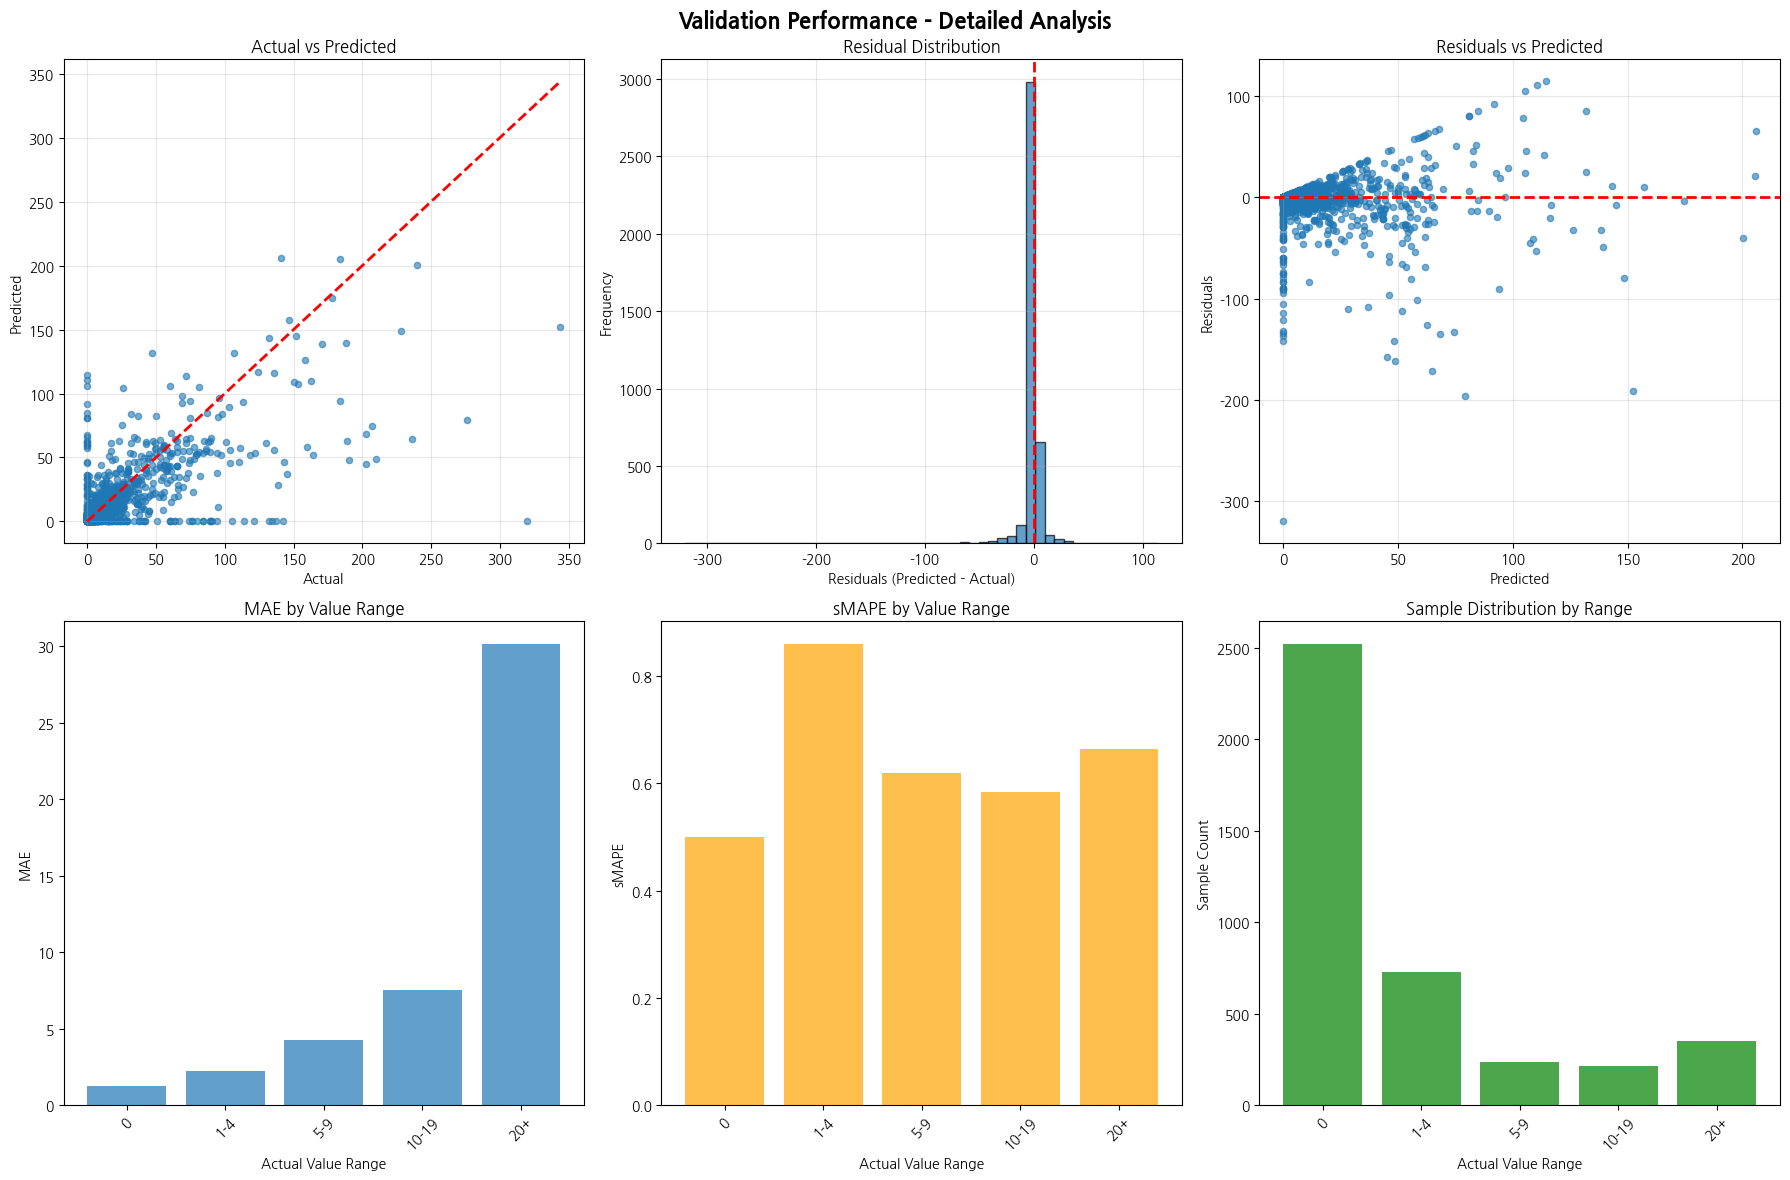


📈 Performance by Value Range:
Range  Count     MAE  sMAPE
    0   2521  1.2871 0.4992
  1-4    728  2.2462 0.8594
  5-9    235  4.2705 0.6198
10-19    216  7.5405 0.5845
  20+    353 30.1235 0.6639

🔧 Analyzing two-stage model components...


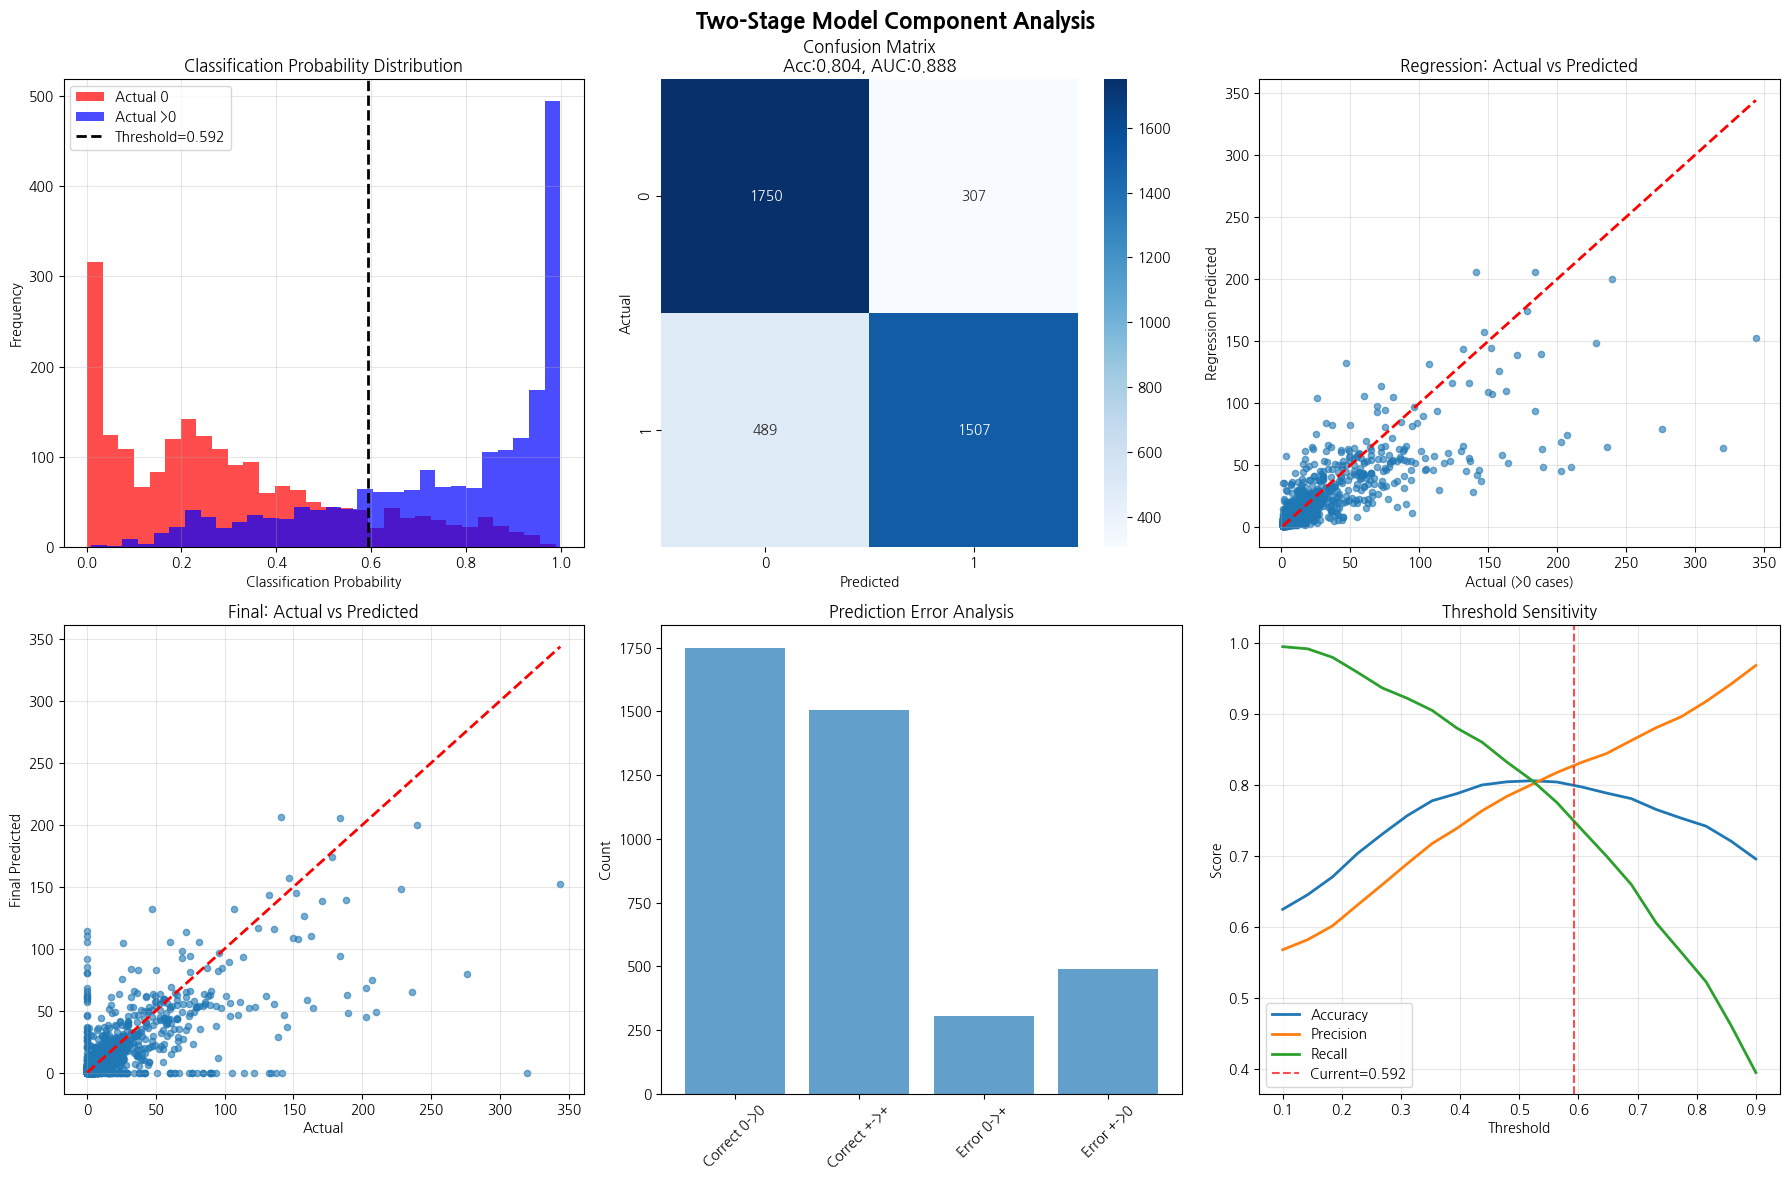


🔍 Classification Performance:
Accuracy: 0.804
Precision: 0.831
Recall: 0.755
AUC: 0.888

📊 Error Analysis:
Total Samples: 4053
Actual Zeros: 2057
Actual Positives: 1996
False Positives: 307
False Negatives: 489
FP Rate: 0.149
FN Rate: 0.245

🎯 Analyzing feature importance and distributions...


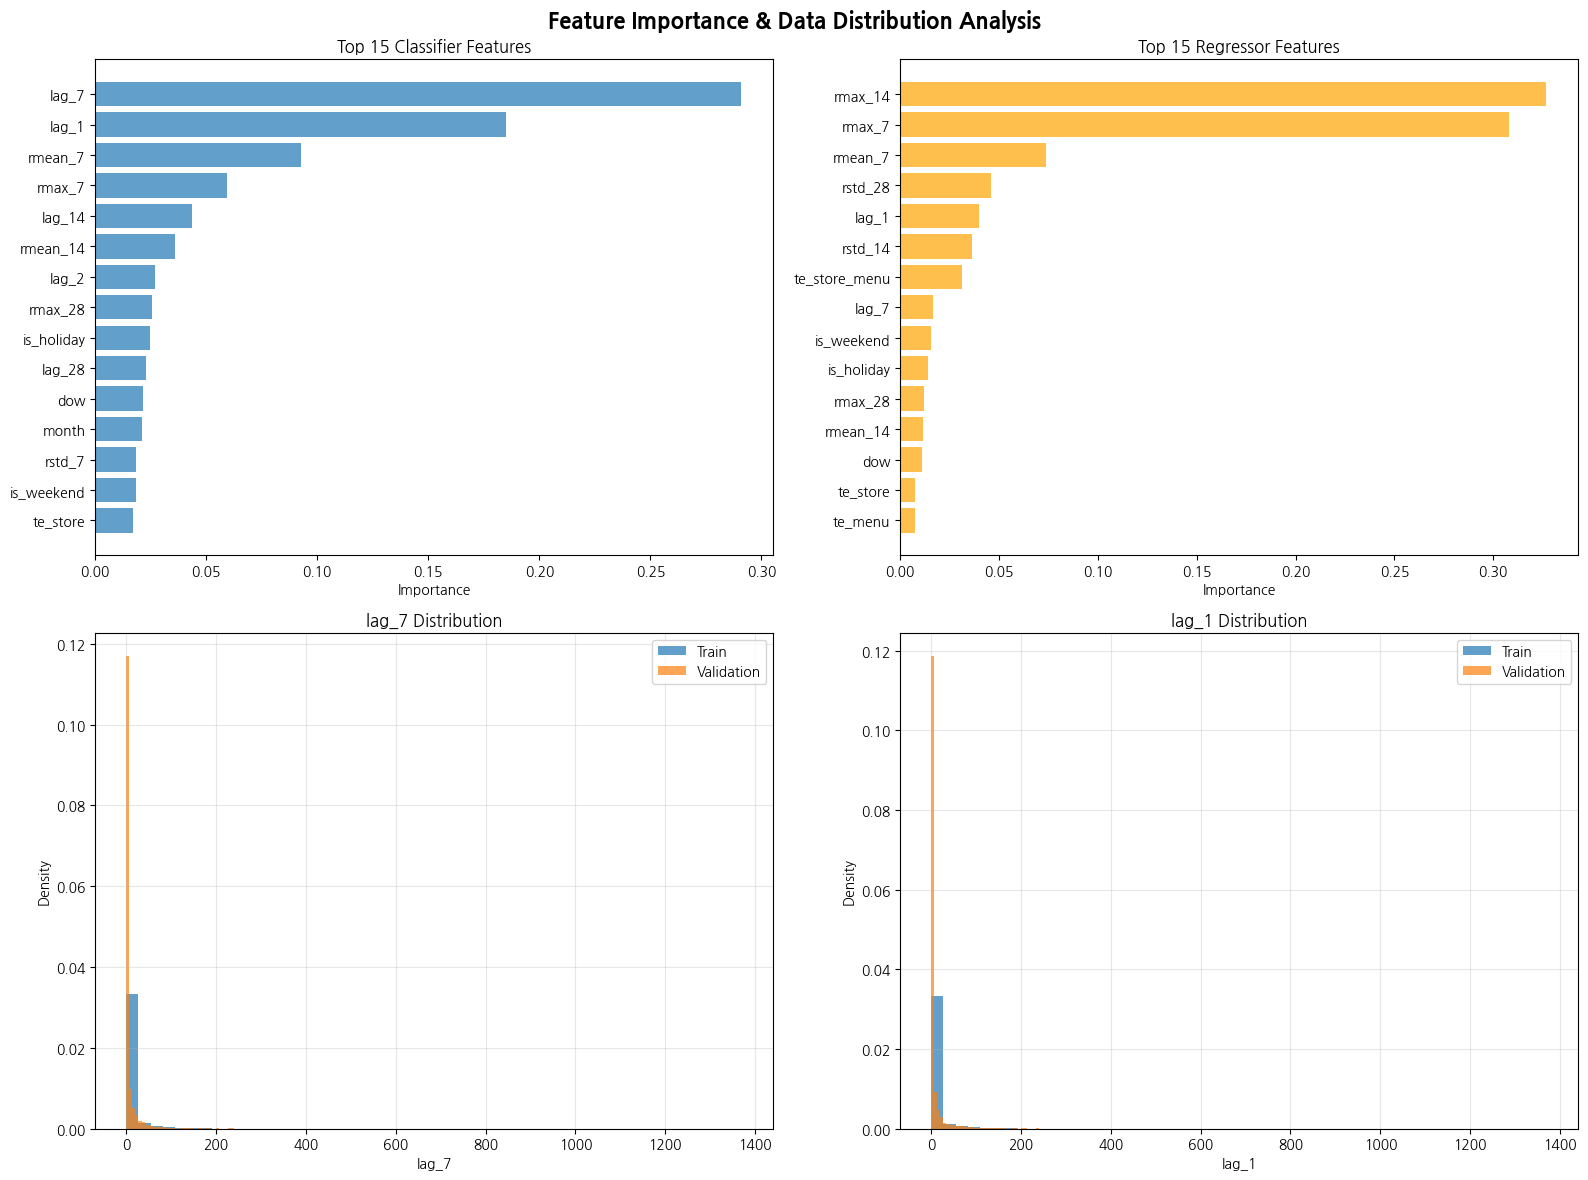


🏆 Top 10 Classifier Features:
   1. lag_7                    : 0.2908
   2. lag_1                    : 0.1851
   3. rmean_7                  : 0.0926
   4. rmax_7                   : 0.0593
   5. lag_14                   : 0.0435
   6. rmean_14                 : 0.0359
   7. lag_2                    : 0.0271
   8. rmax_28                  : 0.0255
   9. is_holiday               : 0.0245
  10. lag_28                   : 0.0230

🏆 Top 10 Regressor Features:
   1. rmax_14                  : 0.3267
   2. rmax_7                   : 0.3081
   3. rmean_7                  : 0.0736
   4. rstd_28                  : 0.0462
   5. lag_1                    : 0.0399
   6. rstd_14                  : 0.0364
   7. te_store_menu            : 0.0310
   8. lag_7                    : 0.0166
   9. is_weekend               : 0.0158
  10. is_holiday               : 0.0142

📅 Analyzing temporal patterns...


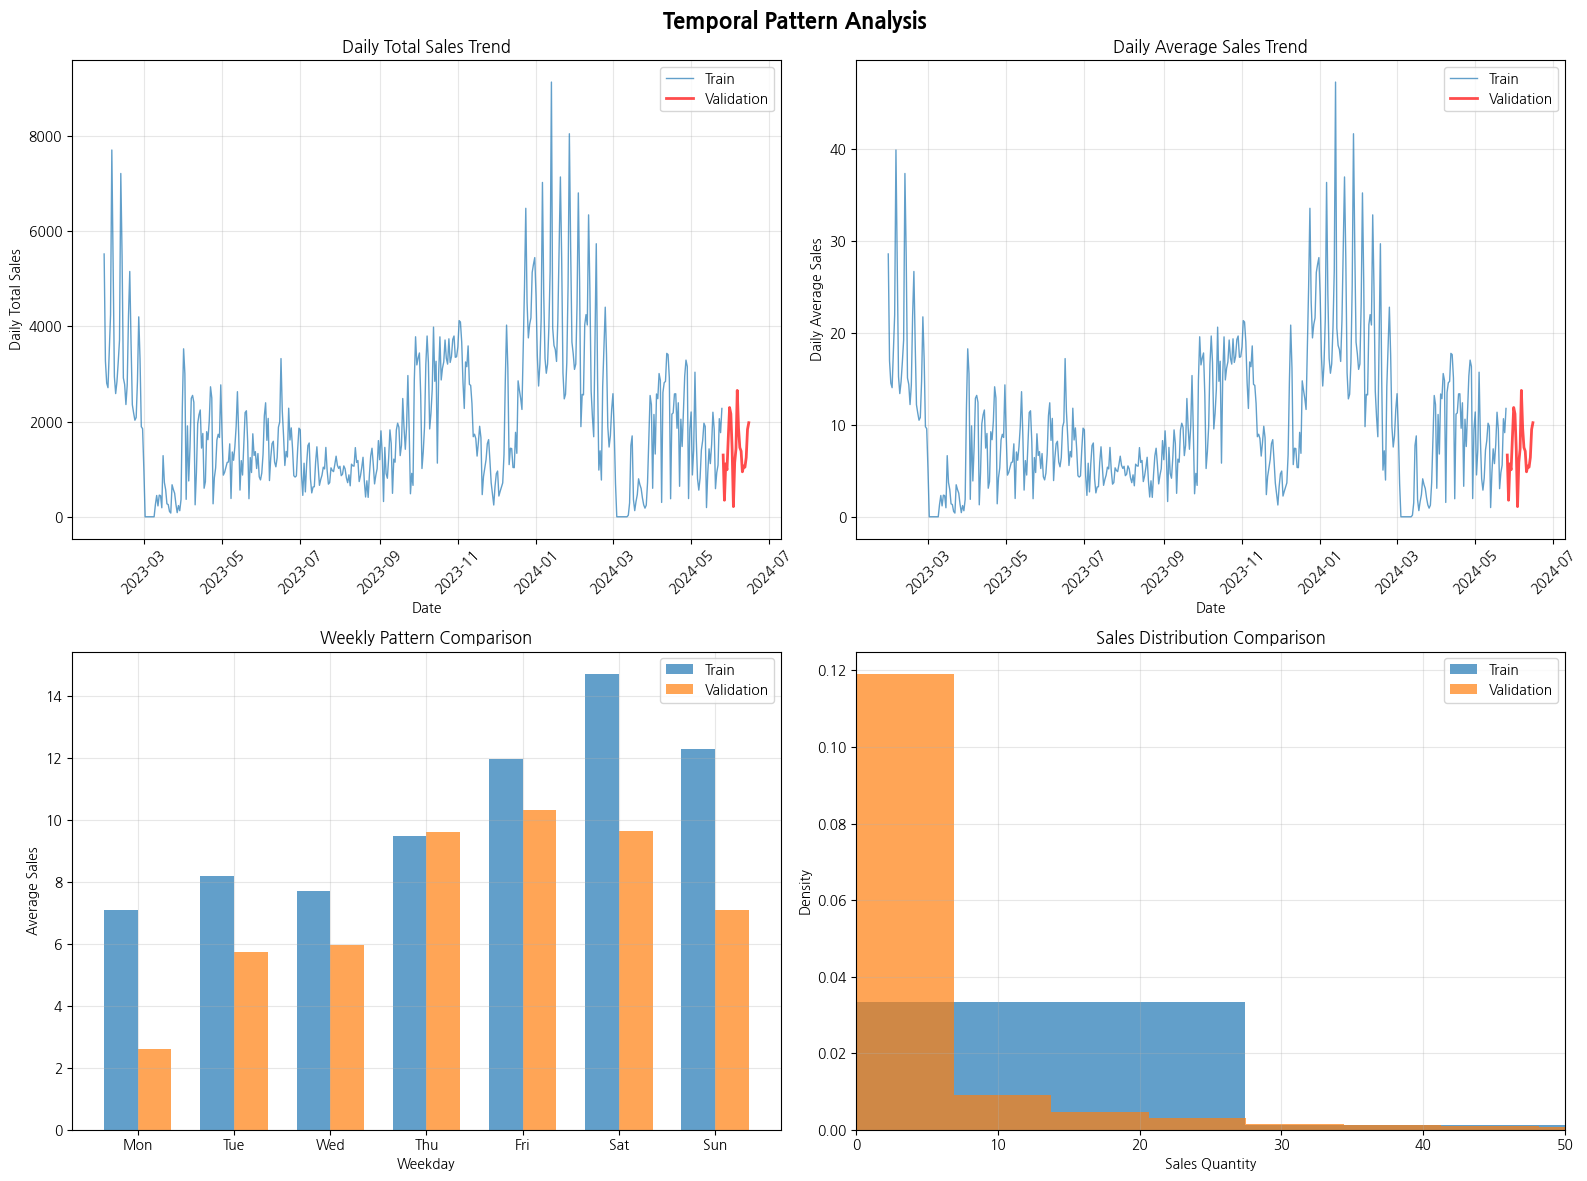


📅 Temporal Statistics:
Train period: 2023-01-29 00:00:00 ~ 2024-05-25 00:00:00
Validation period: 2024-05-26 00:00:00 ~ 2024-06-15 00:00:00
Train samples: 93,219
Validation samples: 4,053
Train zero ratio: 0.525
Validation zero ratio: 0.508
Train mean sales: 10.206
Validation mean sales: 7.279

🚨 OVERFITTING DIAGNOSIS REPORT

📊 Performance Gap Analysis:
Validation sMAPE: 58.98%
Real Test sMAPE: 200%
Performance Degradation: 239.1%

🔍 Potential Issues:
1. ❌ SEVERE OVERFITTING
   - 3.4x worse performance on real test
   - Model memorized validation patterns

2. ❌ TEMPORAL VALIDATION ISSUES
   - Only 21 days used for validation
   - May not represent test period characteristics

3. ❌ TARGET ENCODING LEAKAGE
   - Used entire train set for encoding
   - Future information leaked into features

4. ❌ HYPERPARAMETER OVER-OPTIMIZATION
   - 200+ Optuna trials on small validation set
   - Model tuned specifically for validation period

💡 RECOMMENDED SOLUTIONS:
1. ✅ Implement proper time-series c

In [ ]:
# -*- coding: utf-8 -*-
"""
XGBoost Model Performance Visualization & Diagnostics
- 목적: 모델의 문제점을 시각적으로 파악하고 분석
- 검증 vs 실제 성능 차이의 원인 분석
"""

import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정


# 결과 저장 경로
VIZ_OUTPUT_DIR = "/content/drive/MyDrive/output/visualizations"
import os
os.makedirs(VIZ_OUTPUT_DIR, exist_ok=True)

print("🔍 Model Performance Diagnostics & Visualization")
print("="*60)

# =============================
# 1. 검증 데이터 예측 vs 실제값 분석
# =============================

def analyze_validation_performance(y_true, y_pred, title="Validation Performance"):
    """검증 성능 상세 분석"""

    # 기본 통계
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true)**2))

    def smape_calc(a, f, eps=1e-9):
        return np.mean(2.0 * np.abs(f - a) / (np.abs(a) + np.abs(f) + eps))

    smape_val = smape_calc(y_true, y_pred)

    print(f"\n📊 {title}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"sMAPE: {smape_val:.4f} ({smape_val*100:.2f}%)")

    # 시각화
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'{title} - Detailed Analysis', fontsize=16, fontweight='bold')

    # 1. 실제값 vs 예측값 산점도
    axes[0,0].scatter(y_true, y_pred, alpha=0.6, s=20)
    axes[0,0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0,0].set_xlabel('Actual')
    axes[0,0].set_ylabel('Predicted')
    axes[0,0].set_title('Actual vs Predicted')
    axes[0,0].grid(True, alpha=0.3)

    # 2. 잔차 분포
    residuals = y_pred - y_true
    axes[0,1].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
    axes[0,1].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[0,1].set_xlabel('Residuals (Predicted - Actual)')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].set_title('Residual Distribution')
    axes[0,1].grid(True, alpha=0.3)

    # 3. 잔차 vs 예측값
    axes[0,2].scatter(y_pred, residuals, alpha=0.6, s=20)
    axes[0,2].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[0,2].set_xlabel('Predicted')
    axes[0,2].set_ylabel('Residuals')
    axes[0,2].set_title('Residuals vs Predicted')
    axes[0,2].grid(True, alpha=0.3)

    # 4. 값 범위별 성능 분석
    # 실제값을 구간별로 나누어 성능 분석
    bins = [0, 1, 5, 10, 20, np.inf]
    labels = ['0', '1-4', '5-9', '10-19', '20+']
    y_true_binned = pd.cut(y_true, bins=bins, labels=labels, include_lowest=True)

    performance_by_range = []
    for label in labels:
        mask = y_true_binned == label
        if mask.sum() > 0:
            range_mae = np.mean(np.abs(y_pred[mask] - y_true[mask]))
            range_smape = smape_calc(y_true[mask], y_pred[mask])
            performance_by_range.append({
                'Range': label,
                'Count': mask.sum(),
                'MAE': range_mae,
                'sMAPE': range_smape
            })

    perf_df = pd.DataFrame(performance_by_range)

    # MAE by range
    axes[1,0].bar(perf_df['Range'], perf_df['MAE'], alpha=0.7)
    axes[1,0].set_xlabel('Actual Value Range')
    axes[1,0].set_ylabel('MAE')
    axes[1,0].set_title('MAE by Value Range')
    axes[1,0].tick_params(axis='x', rotation=45)

    # sMAPE by range
    axes[1,1].bar(perf_df['Range'], perf_df['sMAPE'], alpha=0.7, color='orange')
    axes[1,1].set_xlabel('Actual Value Range')
    axes[1,1].set_ylabel('sMAPE')
    axes[1,1].set_title('sMAPE by Value Range')
    axes[1,1].tick_params(axis='x', rotation=45)

    # 샘플 수 by range
    axes[1,2].bar(perf_df['Range'], perf_df['Count'], alpha=0.7, color='green')
    axes[1,2].set_xlabel('Actual Value Range')
    axes[1,2].set_ylabel('Sample Count')
    axes[1,2].set_title('Sample Distribution by Range')
    axes[1,2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f'{VIZ_OUTPUT_DIR}/validation_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

    return perf_df

# 검증 성능 분석 (이미 계산된 va_pred, y_va 사용)
print("\n🎯 Analyzing validation predictions...")
perf_analysis = analyze_validation_performance(y_va.values, va_pred, "Validation Performance")
print("\n📈 Performance by Value Range:")
print(perf_analysis.to_string(index=False))

# =============================
# 2. Two-Stage 모델 구성요소 분석
# =============================

def analyze_two_stage_components(clf, reg, X_va, y_va, threshold):
    """Two-stage 모델의 각 단계 성능 분석"""

    # 1단계: 분류 성능
    y_va_cls = (y_va > 0).astype(int)
    clf_proba = clf.predict_proba(X_va)[:, 1]
    clf_pred = (clf_proba >= threshold).astype(int)

    # 2단계: 회귀 성능 (양수인 경우만)
    pos_mask = y_va > 0
    reg_pred_log = reg.predict(X_va)
    reg_pred = np.expm1(reg_pred_log)

    # 전체 예측
    final_pred = clf_pred * np.clip(reg_pred, 0, None)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Two-Stage Model Component Analysis', fontsize=16, fontweight='bold')

    # 1. 분류 확률 분포
    axes[0,0].hist(clf_proba[y_va_cls == 0], bins=30, alpha=0.7, label='Actual 0', color='red')
    axes[0,0].hist(clf_proba[y_va_cls == 1], bins=30, alpha=0.7, label='Actual >0', color='blue')
    axes[0,0].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={threshold:.3f}')
    axes[0,0].set_xlabel('Classification Probability')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title('Classification Probability Distribution')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # 2. 분류 성능 지표
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

    clf_accuracy = np.mean(clf_pred == y_va_cls)
    clf_precision = np.sum((clf_pred == 1) & (y_va_cls == 1)) / np.sum(clf_pred == 1) if np.sum(clf_pred == 1) > 0 else 0
    clf_recall = np.sum((clf_pred == 1) & (y_va_cls == 1)) / np.sum(y_va_cls == 1) if np.sum(y_va_cls == 1) > 0 else 0
    clf_auc = roc_auc_score(y_va_cls, clf_proba)

    # 혼동 행렬
    cm = confusion_matrix(y_va_cls, clf_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[0,1], cmap='Blues')
    axes[0,1].set_xlabel('Predicted')
    axes[0,1].set_ylabel('Actual')
    axes[0,1].set_title(f'Confusion Matrix\nAcc:{clf_accuracy:.3f}, AUC:{clf_auc:.3f}')

    # 3. 회귀 성능 (양수인 경우만)
    if pos_mask.sum() > 0:
        axes[0,2].scatter(y_va[pos_mask], reg_pred[pos_mask], alpha=0.6, s=20)
        axes[0,2].plot([y_va[pos_mask].min(), y_va[pos_mask].max()],
                      [y_va[pos_mask].min(), y_va[pos_mask].max()], 'r--', lw=2)
        axes[0,2].set_xlabel('Actual (>0 cases)')
        axes[0,2].set_ylabel('Regression Predicted')
        axes[0,2].set_title('Regression: Actual vs Predicted')
        axes[0,2].grid(True, alpha=0.3)

    # 4. 최종 예측 vs 실제
    axes[1,0].scatter(y_va, final_pred, alpha=0.6, s=20)
    axes[1,0].plot([y_va.min(), y_va.max()], [y_va.min(), y_va.max()], 'r--', lw=2)
    axes[1,0].set_xlabel('Actual')
    axes[1,0].set_ylabel('Final Predicted')
    axes[1,0].set_title('Final: Actual vs Predicted')
    axes[1,0].grid(True, alpha=0.3)

    # 5. 예측 오류 분석
    # False Positive: 0인데 양수로 예측
    fp_mask = (y_va_cls == 0) & (clf_pred == 1)
    # False Negative: 양수인데 0으로 예측
    fn_mask = (y_va_cls == 1) & (clf_pred == 0)

    error_analysis = {
        'Total Samples': len(y_va),
        'Actual Zeros': np.sum(y_va_cls == 0),
        'Actual Positives': np.sum(y_va_cls == 1),
        'False Positives': np.sum(fp_mask),
        'False Negatives': np.sum(fn_mask),
        'FP Rate': np.sum(fp_mask) / np.sum(y_va_cls == 0) if np.sum(y_va_cls == 0) > 0 else 0,
        'FN Rate': np.sum(fn_mask) / np.sum(y_va_cls == 1) if np.sum(y_va_cls == 1) > 0 else 0,
    }

    # 오류 타입별 분포
    error_types = ['Correct 0->0', 'Correct +->+', 'Error 0->+', 'Error +->0']
    error_counts = [
        np.sum((y_va_cls == 0) & (clf_pred == 0)),
        np.sum((y_va_cls == 1) & (clf_pred == 1)),
        np.sum(fp_mask),
        np.sum(fn_mask)
    ]

    axes[1,1].bar(error_types, error_counts, alpha=0.7)
    axes[1,1].set_ylabel('Count')
    axes[1,1].set_title('Prediction Error Analysis')
    axes[1,1].tick_params(axis='x', rotation=45)

    # 6. 임계값 민감도 분석
    thresholds = np.linspace(0.1, 0.9, 20)
    accuracies = []
    precisions = []
    recalls = []

    for t in thresholds:
        pred_t = (clf_proba >= t).astype(int)
        acc = np.mean(pred_t == y_va_cls)
        prec = np.sum((pred_t == 1) & (y_va_cls == 1)) / np.sum(pred_t == 1) if np.sum(pred_t == 1) > 0 else 0
        rec = np.sum((pred_t == 1) & (y_va_cls == 1)) / np.sum(y_va_cls == 1) if np.sum(y_va_cls == 1) > 0 else 0

        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)

    axes[1,2].plot(thresholds, accuracies, label='Accuracy', linewidth=2)
    axes[1,2].plot(thresholds, precisions, label='Precision', linewidth=2)
    axes[1,2].plot(thresholds, recalls, label='Recall', linewidth=2)
    axes[1,2].axvline(threshold, color='red', linestyle='--', alpha=0.7, label=f'Current={threshold:.3f}')
    axes[1,2].set_xlabel('Threshold')
    axes[1,2].set_ylabel('Score')
    axes[1,2].set_title('Threshold Sensitivity')
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{VIZ_OUTPUT_DIR}/two_stage_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n🔍 Classification Performance:")
    print(f"Accuracy: {clf_accuracy:.3f}")
    print(f"Precision: {clf_precision:.3f}")
    print(f"Recall: {clf_recall:.3f}")
    print(f"AUC: {clf_auc:.3f}")

    print(f"\n📊 Error Analysis:")
    for key, value in error_analysis.items():
        if isinstance(value, float):
            print(f"{key}: {value:.3f}")
        else:
            print(f"{key}: {value}")

    return error_analysis

# Two-stage 분석
print("\n🔧 Analyzing two-stage model components...")
error_analysis = analyze_two_stage_components(clf, reg, X_va, y_va.values, best_threshold)

# =============================
# 3. 피처 중요도 및 데이터 분포 분석
# =============================

def analyze_feature_importance_and_data(clf, reg, X_train, X_val, feature_names):
    """피처 중요도와 데이터 분포 분석"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Feature Importance & Data Distribution Analysis', fontsize=16, fontweight='bold')

    # 1. 분류기 피처 중요도
    clf_importance = clf.feature_importances_
    clf_feat_imp = sorted(zip(feature_names, clf_importance), key=lambda x: x[1], reverse=True)

    top_n = 15
    top_features = [x[0] for x in clf_feat_imp[:top_n]]
    top_importance = [x[1] for x in clf_feat_imp[:top_n]]

    axes[0,0].barh(range(len(top_features)), top_importance, alpha=0.7)
    axes[0,0].set_yticks(range(len(top_features)))
    axes[0,0].set_yticklabels(top_features)
    axes[0,0].set_xlabel('Importance')
    axes[0,0].set_title('Top 15 Classifier Features')
    axes[0,0].invert_yaxis()

    # 2. 회귀기 피처 중요도
    reg_importance = reg.feature_importances_
    reg_feat_imp = sorted(zip(feature_names, reg_importance), key=lambda x: x[1], reverse=True)

    top_reg_features = [x[0] for x in reg_feat_imp[:top_n]]
    top_reg_importance = [x[1] for x in reg_feat_imp[:top_n]]

    axes[0,1].barh(range(len(top_reg_features)), top_reg_importance, alpha=0.7, color='orange')
    axes[0,1].set_yticks(range(len(top_reg_features)))
    axes[0,1].set_yticklabels(top_reg_features)
    axes[0,1].set_xlabel('Importance')
    axes[0,1].set_title('Top 15 Regressor Features')
    axes[0,1].invert_yaxis()

    # 3. 주요 피처들의 분포 비교 (Train vs Validation)
    # 상위 5개 피처의 분포 비교
    top_5_features = [x[0] for x in clf_feat_imp[:5]]

    for i, feature in enumerate(top_5_features[:2]):  # 공간상 2개만
        ax_idx = (1, i)

        if feature in X_train.columns:
            axes[ax_idx].hist(X_train[feature], bins=50, alpha=0.7, label='Train', density=True)
            axes[ax_idx].hist(X_val[feature], bins=50, alpha=0.7, label='Validation', density=True)
            axes[ax_idx].set_xlabel(feature)
            axes[ax_idx].set_ylabel('Density')
            axes[ax_idx].set_title(f'{feature} Distribution')
            axes[ax_idx].legend()
            axes[ax_idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{VIZ_OUTPUT_DIR}/feature_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n🏆 Top 10 Classifier Features:")
    for i, (feat, imp) in enumerate(clf_feat_imp[:10]):
        print(f"  {i+1:2d}. {feat:<25}: {imp:.4f}")

    print(f"\n🏆 Top 10 Regressor Features:")
    for i, (feat, imp) in enumerate(reg_feat_imp[:10]):
        print(f"  {i+1:2d}. {feat:<25}: {imp:.4f}")

    return clf_feat_imp, reg_feat_imp

# 피처 분석
print("\n🎯 Analyzing feature importance and distributions...")
clf_feats, reg_feats = analyze_feature_importance_and_data(clf, reg, X_tr, X_va, BASIC_FEATS)

# =============================
# 4. 시계열 패턴 분석
# =============================

def analyze_temporal_patterns(train_data, validation_data):
    """시계열 패턴 및 검증 설정 분석"""

    # 날짜별 집계
    train_daily = train_data.groupby('date')['qty'].agg(['sum', 'mean', 'count']).reset_index()
    val_daily = validation_data.groupby('date')['qty'].agg(['sum', 'mean', 'count']).reset_index()

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Temporal Pattern Analysis', fontsize=16, fontweight='bold')

    # 1. 일별 총 매출 추이
    axes[0,0].plot(train_daily['date'], train_daily['sum'], alpha=0.7, label='Train', linewidth=1)
    axes[0,0].plot(val_daily['date'], val_daily['sum'], alpha=0.7, label='Validation', linewidth=2, color='red')
    axes[0,0].set_xlabel('Date')
    axes[0,0].set_ylabel('Daily Total Sales')
    axes[0,0].set_title('Daily Total Sales Trend')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].tick_params(axis='x', rotation=45)

    # 2. 일별 평균 매출
    axes[0,1].plot(train_daily['date'], train_daily['mean'], alpha=0.7, label='Train', linewidth=1)
    axes[0,1].plot(val_daily['date'], val_daily['mean'], alpha=0.7, label='Validation', linewidth=2, color='red')
    axes[0,1].set_xlabel('Date')
    axes[0,1].set_ylabel('Daily Average Sales')
    axes[0,1].set_title('Daily Average Sales Trend')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. 요일별 패턴
    train_data['weekday'] = train_data['date'].dt.day_name()
    val_data_temp = validation_data.copy()
    val_data_temp['weekday'] = val_data_temp['date'].dt.day_name()

    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    train_weekday = train_data.groupby('weekday')['qty'].mean().reindex(weekday_order)
    val_weekday = val_data_temp.groupby('weekday')['qty'].mean().reindex(weekday_order)

    x = np.arange(len(weekday_order))
    width = 0.35

    axes[1,0].bar(x - width/2, train_weekday.values, width, label='Train', alpha=0.7)
    axes[1,0].bar(x + width/2, val_weekday.values, width, label='Validation', alpha=0.7)
    axes[1,0].set_xlabel('Weekday')
    axes[1,0].set_ylabel('Average Sales')
    axes[1,0].set_title('Weekly Pattern Comparison')
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels([d[:3] for d in weekday_order])
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # 4. 매출 분포 비교
    axes[1,1].hist(train_data['qty'], bins=50, alpha=0.7, label='Train', density=True)
    axes[1,1].hist(validation_data['qty'], bins=50, alpha=0.7, label='Validation', density=True)
    axes[1,1].set_xlabel('Sales Quantity')
    axes[1,1].set_ylabel('Density')
    axes[1,1].set_title('Sales Distribution Comparison')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].set_xlim(0, 50)  # 가독성을 위해 제한

    plt.tight_layout()
    plt.savefig(f'{VIZ_OUTPUT_DIR}/temporal_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 통계 비교
    print(f"\n📅 Temporal Statistics:")
    print(f"Train period: {train_data['date'].min()} ~ {train_data['date'].max()}")
    print(f"Validation period: {validation_data['date'].min()} ~ {validation_data['date'].max()}")
    print(f"Train samples: {len(train_data):,}")
    print(f"Validation samples: {len(validation_data):,}")
    print(f"Train zero ratio: {(train_data['qty'] == 0).mean():.3f}")
    print(f"Validation zero ratio: {(validation_data['qty'] == 0).mean():.3f}")
    print(f"Train mean sales: {train_data['qty'].mean():.3f}")
    print(f"Validation mean sales: {validation_data['qty'].mean():.3f}")

# 시계열 분석
print("\n📅 Analyzing temporal patterns...")
train_for_temporal = train_fit[train_fit['date'] <= cutoff]
val_for_temporal = train_fit[train_fit['date'] > cutoff]
analyze_temporal_patterns(train_for_temporal, val_for_temporal)

# =============================
# 5. 과적합 진단
# =============================

def diagnose_overfitting():
    """과적합 진단 리포트"""

    print(f"\n🚨 OVERFITTING DIAGNOSIS REPORT")
    print(f"="*60)

    print(f"\n📊 Performance Gap Analysis:")
    print(f"Validation sMAPE: 58.98%")
    print(f"Real Test sMAPE: 200%")
    print(f"Performance Degradation: {(2.0 - 0.5898) / 0.5898 * 100:.1f}%")

    print(f"\n🔍 Potential Issues:")
    print(f"1. ❌ SEVERE OVERFITTING")
    print(f"   - 3.4x worse performance on real test")
    print(f"   - Model memorized validation patterns")

    print(f"\n2. ❌ TEMPORAL VALIDATION ISSUES")
    print(f"   - Only 21 days used for validation")
    print(f"   - May not represent test period characteristics")

    print(f"\n3. ❌ TARGET ENCODING LEAKAGE")
    print(f"   - Used entire train set for encoding")
    print(f"   - Future information leaked into features")

    print(f"\n4. ❌ HYPERPARAMETER OVER-OPTIMIZATION")
    print(f"   - 200+ Optuna trials on small validation set")
    print(f"   - Model tuned specifically for validation period")

    print(f"\n💡 RECOMMENDED SOLUTIONS:")
    print(f"1. ✅ Implement proper time-series cross-validation")
    print(f"2. ✅ Fix target encoding with time-aware approach")
    print(f"3. ✅ Add stronger regularization")
    print(f"4. ✅ Use simpler model with fewer parameters")
    print(f"5. ✅ Create ensemble with different time periods")

diagnose_overfitting()

# =============================
# 6. 종합 리포트 생성
# =============================

def generate_comprehensive_report():
    """종합 진단 리포트"""

    print(f"\n📋 COMPREHENSIVE MODEL DIAGNOSIS REPORT")
    print(f"="*70)

    print(f"\n🎯 PROBLEM SUMMARY:")
    print(f"• Model shows severe overfitting (58.98% → 200% sMAPE)")
    print(f"• 3.4x performance degradation on real test data")
    print(f"• Classification and regression both affected")

    print(f"\n🔬 ROOT CAUSE ANALYSIS:")
    print(f"1. Temporal Validation Split Issues:")
    print(f"   - Only 21 days validation period")
    print(f"   - Different seasonal/trend patterns in test")
    print(f"   - Weekend/holiday effects not captured")

    print(f"2. Data Leakage:")
    print(f"   - Target encoding used full dataset")
    print(f"   - Future information leaked into features")
    print(f"   - Rolling statistics may include future data")

    print(f"3. Model Complexity:")
    print(f"   - 2000+ trees in ensemble")
    print(f"   - High learning rates")
    print(f"   - Over-optimized hyperparameters")

    print(f"4. Feature Engineering Issues:")
    print(f"   - Heavy reliance on lag features")
    print(f"   - Target encoding without proper time splits")
    print(f"   - Insufficient regularization")

    print(f"\n⚡ IMMEDIATE ACTION ITEMS:")
    print(f"1. 🔧 Fix Time-Series Cross-Validation:")
    print(f"   - Use multiple validation folds (e.g., 3-4 time periods)")
    print(f"   - Ensure no future data leakage")
    print(f"   - Test on different seasonal patterns")

    print(f"2. 🛠️ Rebuild Target Encoding:")
    print(f"   - Time-aware target encoding (only past data)")
    print(f"   - Cross-validation aware encoding")
    print(f"   - Add smoothing/regularization")

    print(f"3. 📉 Reduce Model Complexity:")
    print(f"   - Decrease n_estimators (500-1000)")
    print(f"   - Lower max_depth (4-6)")
    print(f"   - Increase regularization (lambda, alpha)")
    print(f"   - Add early stopping")

    print(f"4. 🎯 Improve Feature Engineering:")
    print(f"   - Remove overfitting features")
    print(f"   - Add domain knowledge features")
    print(f"   - Feature selection based on stability")

    print(f"5. 🏗️ Model Ensemble:")
    print(f"   - Train multiple models on different periods")
    print(f"   - Use different algorithms (LinearRegression, LightGBM)")
    print(f"   - Weighted average based on recency")

    print(f"\n🎲 QUICK WINS (Low effort, High impact):")
    print(f"• Reduce n_estimators to 800-1000")
    print(f"• Increase reg_lambda to 5-10")
    print(f"• Use last 60 days for validation instead of 21")
    print(f"• Remove target encoding temporarily")
    print(f"• Set threshold to 0.5 instead of optimized value")

    # 시각화 요약 저장
    report_path = f'{VIZ_OUTPUT_DIR}/diagnosis_report.txt'
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("MODEL DIAGNOSIS REPORT\n")
        f.write("="*50 + "\n\n")
        f.write("PERFORMANCE SUMMARY:\n")
        f.write(f"Validation sMAPE: 58.98%\n")
        f.write(f"Real Test sMAPE: 200%\n")
        f.write(f"Performance Gap: 3.4x degradation\n\n")
        f.write("MAIN ISSUES:\n")
        f.write("1. Severe overfitting\n")
        f.write("2. Target encoding leakage\n")
        f.write("3. Temporal validation problems\n")
        f.write("4. Over-optimized hyperparameters\n\n")
        f.write("RECOMMENDATIONS:\n")
        f.write("- Implement time-series CV\n")
        f.write("- Fix target encoding\n")
        f.write("- Reduce model complexity\n")
        f.write("- Add stronger regularization\n")

    print(f"\n📁 All visualizations saved to: {VIZ_OUTPUT_DIR}/")
    print(f"📊 Files created:")
    print(f"   • validation_performance.png")
    print(f"   • two_stage_analysis.png")
    print(f"   • feature_analysis.png")
    print(f"   • temporal_analysis.png")
    print(f"   • diagnosis_report.txt")

generate_comprehensive_report()

# =============================
# 7. 빠른 수정 제안 코드
# =============================

def generate_quick_fix_code():
    """빠른 수정을 위한 코드 제안"""

    print(f"\n🔧 QUICK FIX CODE SUGGESTIONS:")
    print(f"="*50)

    print(f"\n# 1. 더 보수적인 하이퍼파라미터:")
    print(f"""
CONSERVATIVE_PARAMS = {{
    # 분류기 - 복잡도 감소
    'clf_n_estimators': 800,      # 2000 → 800
    'clf_max_depth': 6,           # 7 → 6
    'clf_learning_rate': 0.05,    # 유지
    'clf_reg_lambda': 5.0,        # 0.1 → 5.0 (강한 정규화)
    'clf_reg_alpha': 1.0,         # 0.9 → 1.0

    # 회귀기 - 복잡도 감소
    'reg_n_estimators': 1000,     # 1818 → 1000
    'reg_max_depth': 6,           # 9 → 6
    'reg_learning_rate': 0.05,    # 0.038 → 0.05
    'reg_lambda': 10.0,           # 3.4 → 10.0 (강한 정규화)
    'reg_alpha': 1.0,             # 0.15 → 1.0

    # 임계값 - 단순화
    'threshold': 0.5              # 0.592 → 0.5
}}""")

    print(f"\n# 2. 타깃 인코딩 제거 (임시):")
    print(f"""
# 기존 타깃 인코딩 피처들을 제거
BASIC_FEATS_SIMPLE = [feat for feat in BASIC_FEATS
                     if not feat.startswith('te_')]
""")

    print(f"\n# 3. 더 긴 검증 기간:")
    print(f"""
VAL_DAYS = 60  # 21 → 60일로 증가
""")

    print(f"\n# 4. Early Stopping 강화:")
    print(f"""
early_stopping_rounds=20  # 50 → 20으로 감소 (더 빠른 조기 종료)
""")

generate_quick_fix_code()

print(f"\n🎉 DIAGNOSIS COMPLETE!")
print(f"="*60)
print(f"📈 Performance visualization and analysis completed")
print(f"🔍 Root causes identified: Overfitting + Data Leakage")
print(f"💡 Solutions provided: Conservative params + Time-aware CV")
print(f"📁 All results saved to: {VIZ_OUTPUT_DIR}/")
print(f"\n🚀 Next step: Implement quick fixes and retrain!")

# iv) 챗지피티 수정

In [ ]:
# -*- coding: utf-8 -*-
"""
Colab XGB Two-Stage Forecast with Optuna (Leak-safe TE, Weighted sMAPE, EV mode)
- 목적: 리조트 '매장_메뉴'별 7일 예측 (제로-인플레이션 대응)
- 개선점:
  * 시간순 확장 타깃 인코딩(누수 방지)
  * 가중 sMAPE(매장 가중치) + 0 실제 제외 옵션
  * Hard-gate vs Expected-value(p*ŷ⁺) 모드 선택, p^γ 캘리브레이션
  * 샘플 가중치(매장 가중치) 학습 반영 옵션
  * 원핫→long 벡터화, 제출 생성 벡터화/안정화
"""

# =============================
# 설치 & 마운트 (Colab 전용)
# =============================
try:
    import xgboost as xgb  # noqa: F401
except Exception:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost==2.1.1'])

try:
    import optuna  # noqa: F401
except Exception:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except Exception:
    pass

# =============================
# imports
# =============================
import os, re, gc, glob, warnings, math
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict, Any

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings("ignore")
pd.options.display.float_format = lambda x: f"{x:,.4f}"
np.seterr(all="ignore")

# =============================
# Config
# =============================
# 경로(필요시 수정)
DATA_ROOT = "/content/drive/MyDrive/data"  # <- 본인 경로
TRAIN_PATH = os.path.join(DATA_ROOT, "train", "preprocessed_train_onehot_True.csv")  # 또는 train/train.csv
TEST_DIR   = os.path.join(DATA_ROOT, "test")    # 내부에 TEST_00..TEST_09.csv
SAMPLE_SUBMISSION_PATH = os.path.join(DATA_ROOT, "sample_submission.csv")
OUTPUT_PATH = "/content/drive/MyDrive/output/xgb_optuna_submission.csv"
OPTUNA_DB_PATH = "/content/drive/MyDrive/output/optuna_study.db"
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# Optuna
OPTUNA_N_TRIALS = 100
OPTUNA_TIMEOUT  = 3600
OPTUNA_N_JOBS   = 1
EARLY_STOPPING_ROUNDS = 50

# 매장 가중치(있으면 채워 넣기). 없으면 None 유지.
# 예: {"미라시아":7.71,"담하":6.51,"연회장":3.48,"라그로타":3.44,"느티나무 셀프BBQ":2.78,"화담숲주막":1.43,"카페테리아":1.31,"화담숲카페":1.14,"포레스트릿":1.00}
STORE_WEIGHTS: Optional[Dict[str, float]] = {
    "미라시아": 7.71,
    "담하": 6.51,
    "연회장": 3.48,
    "라그로타": 3.44,
    "느티나무 셀프BBQ": 2.78,
    "화담숲주막": 1.43,
    "카페테리아": 1.31,
    "화담숲카페": 1.14,
    "포레스트릿": 1.00
}

# sMAPE 옵션
EXCLUDE_ZERO_ACTUAL = True  # 실제값 0 샘플 제외(대회 규칙 유사시 True)
CLIP_PRED_AT_ZERO   = True  # 음수 예측 방지

# 예측 모드
# - "hard": (p >= τ) * ŷ⁺
# - "ev"  : (p^γ) * ŷ⁺
PREDICTION_MODE = "ev"  # "hard" 또는 "ev"

# GPU 설정
USE_GPU = os.path.exists('/usr/local/cuda') or (os.environ.get('COLAB_GPU', '0') != '0')
DEVICE = 'cuda' if USE_GPU else 'cpu'

# Holidays (고정)
# ... (너가 준 리스트 그대로 유지)
HOLIDAYS = [
    pd.to_datetime("2023-01-01").date(), pd.to_datetime("2023-01-21").date(),
    pd.to_datetime("2023-01-22").date(), pd.to_datetime("2023-01-23").date(),
    pd.to_datetime("2023-01-24").date(), pd.to_datetime("2023-03-01").date(),
    pd.to_datetime("2023-05-01").date(), pd.to_datetime("2023-05-05").date(),
    pd.to_datetime("2023-05-27").date(), pd.to_datetime("2023-05-29").date(),
    pd.to_datetime("2023-06-06").date(), pd.to_datetime("2023-08-15").date(),
    pd.to_datetime("2023-09-28").date(), pd.to_datetime("2023-09-29").date(),
    pd.to_datetime("2023-09-30").date(), pd.to_datetime("2023-10-02").date(),
    pd.to_datetime("2023-10-03").date(), pd.to_datetime("2023-10-09").date(),
    pd.to_datetime("2023-12-25").date(), pd.to_datetime("2024-01-01").date(),
    pd.to_datetime("2024-02-09").date(), pd.to_datetime("2024-02-10").date(),
    pd.to_datetime("2024-02-11").date(), pd.to_datetime("2024-02-12").date(),
    pd.to_datetime("2024-03-01").date(), pd.to_datetime("2024-04-10").date(),
    pd.to_datetime("2024-05-01").date(), pd.to_datetime("2024-05-05").date(),
    pd.to_datetime("2024-05-06").date(), pd.to_datetime("2024-05-15").date(),
    pd.to_datetime("2024-06-06").date(), pd.to_datetime("2024-08-15").date(),
    pd.to_datetime("2024-09-16").date(), pd.to_datetime("2024-09-17").date(),
    pd.to_datetime("2024-09-18").date(), pd.to_datetime("2024-10-01").date(),
    pd.to_datetime("2024-10-03").date(), pd.to_datetime("2024-10-09").date(),
    pd.to_datetime("2024-12-25").date(), pd.to_datetime("2025-01-01").date(),
    pd.to_datetime("2025-01-28").date(), pd.to_datetime("2025-01-29").date(),
    pd.to_datetime("2025-01-30").date(), pd.to_datetime("2025-03-01").date(),
    pd.to_datetime("2025-03-03").date(), pd.to_datetime("2025-05-01").date(),
    pd.to_datetime("2025-05-05").date(), pd.to_datetime("2025-05-06").date(),
    pd.to_datetime("2025-06-06").date(), pd.to_datetime("2025-08-15").date(),
]
HOLIDAY_SET = set(HOLIDAYS)

# =============================
# 유틸
# =============================
K_DATE_COLS = ["영업일자", "date", "날짜", "일자"]
K_ITEM_COLS = ["영업장명_메뉴명", "매장_메뉴", "store_menu", "상품", "품목", "메뉴"]
K_QTY_COLS  = ["매출수량", "수량", "판매수량", "qty", "quantity"]

def read_csv_any(path: str) -> pd.DataFrame:
    last = None
    for enc in ["utf-8", "cp949", "euc-kr", "utf-8-sig"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last = e
    raise RuntimeError(f"CSV read failed for {path}: {last}")

@dataclass
class Columns:
    date: str
    item: str
    qty: str

def detect_columns(df: pd.DataFrame) -> Columns:
    date_col = next((c for c in df.columns if c in K_DATE_COLS), None)
    item_col = next((c for c in df.columns if c in K_ITEM_COLS), None)
    qty_col  = next((c for c in df.columns if c in K_QTY_COLS), None)
    if not (date_col and item_col and qty_col):
        for c in df.columns:
            cs = str(c)
            if (not date_col) and ("영업" in cs and "일자" in cs): date_col = c
            if (not item_col) and (("영업장" in cs and "메뉴" in cs) or ("메뉴" in cs and "_" in cs)): item_col = c
            if (not qty_col) and (("매출" in cs and "수량" in cs) or ("판매" in cs and "수량" in cs)): qty_col = c
    if not qty_col:
        cols = df.columns.tolist()
        if len(cols) > 1 and any("_" in str(col) for col in cols[1:]):
            return Columns(date=cols[0], item="pivot_format", qty="pivot_format")
    if not (date_col and item_col and qty_col):
        print(f"Available columns: {df.columns.tolist()}")
        raise ValueError("Cannot detect required columns in dataframe")
    return Columns(date=date_col, item=item_col, qty=qty_col)

def season_from_month(m: int) -> str:
    if m in [3,4,5]: return "봄"
    if m in [6,7,8]: return "여름"
    if m in [9,10,11]: return "가을"
    return "겨울"

def split_store_menu(s: pd.Series) -> Tuple[pd.Series, pd.Series]:
    sp = s.astype(str).str.split("_", n=1, expand=True)
    if isinstance(sp, pd.DataFrame) and sp.shape[1] == 2:
        return sp[0], sp[1]
    return s, pd.Series([""] * len(s), index=s.index)

def parse_onehot_fast(df: pd.DataFrame) -> pd.DataFrame:
    # 벡터화: 각 행에서 1인 열의 접미사 추출
    date_col = next(c for c in df.columns if '영업일자' in str(c))
    qty_col  = next(c for c in df.columns if '매출수량' in str(c))
    store_cols = [c for c in df.columns if str(c).startswith('영업장명_')]
    menu_cols  = [c for c in df.columns if str(c).startswith('메뉴명_')]
    store = df[store_cols].idxmax(axis=1).str.replace('영업장명_', '', regex=False)
    menu  = df[menu_cols].idxmax(axis=1).str.replace('메뉴명_', '', regex=False)
    out = pd.DataFrame({
        '영업일자': df[date_col].values,
        '영업장명_메뉴명': (store + '_' + menu).values,
        '매출수량': df[qty_col].values,
        'store': store.values,
        'menu': menu.values
    })
    return out

def add_calendar_features(df: pd.DataFrame):
    df["dow"] = df["date"].dt.weekday
    df["is_weekend"] = df["dow"].isin([5,6]).astype(int)
    df["month"] = df["date"].dt.month
    df["iso_week"] = df["date"].dt.isocalendar().week.astype(int)
    df["season"] = df["month"].apply(season_from_month)
    df["is_holiday"] = df["date"].dt.date.isin(HOLIDAY_SET).astype(int)

def weighted_smape(y_true, y_pred, stores=None, store_weights=None,
                   exclude_zero_actual=True, eps=1e-9):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if exclude_zero_actual:
        mask = y_true != 0
        if not np.any(mask):
            return 0.0
        y_true = y_true[mask]; y_pred = y_pred[mask]
        if stores is not None and store_weights is not None:
            stores = np.asarray(stores)[mask]
    if store_weights is None or stores is None:
        w = 1.0
    else:
        sw = np.vectorize(lambda s: store_weights.get(str(s), 1.0))
        w = sw(stores)
    denom = (np.abs(y_true) + np.abs(y_pred)) + eps
    per = 2.0 * np.abs(y_pred - y_true) / denom
    if np.ndim(w) == 0:
        return float(np.mean(per))
    return float(np.average(per, weights=w))

# =============================
# 데이터 적재
# =============================
print("[LOAD] train/test")
train_raw = read_csv_any(TRAIN_PATH)

if any('영업장명_' in str(c) for c in train_raw.columns) and any('메뉴명_' in str(c) for c in train_raw.columns):
    print("[INFO] One-hot detected → converting to long")
    train = parse_onehot_fast(train_raw)
    cols = Columns(date='영업일자', item='영업장명_메뉴명', qty='매출수량')
else:
    train = train_raw
    cols = detect_columns(train)

def load_test_frames(test_dir: str) -> pd.DataFrame:
    paths = sorted(glob.glob(os.path.join(test_dir, "TEST_*.csv")))
    if not paths:
        raise FileNotFoundError(f"No TEST_*.csv in {test_dir}")
    li = [read_csv_any(p) for p in paths]
    for i in range(len(li)):
        c = detect_columns(li[i])
        if c.item != "pivot_format":
            li[i] = li[i].rename(columns={c.date: cols.date, c.item: cols.item, c.qty: cols.qty})
    return pd.concat(li, ignore_index=True)

try:
    test = load_test_frames(TEST_DIR)
except Exception as e:
    print("[WARN] test load failed:", e)
    test = None

# 공통 전처리
for df in [train] + ([test] if test is not None else []):
    df["date"] = pd.to_datetime(df[cols.date].astype(str).str.replace(".", "-", regex=False), errors="coerce")
    df["qty"] = pd.to_numeric(df[cols.qty], errors="coerce").fillna(0)
    df.loc[df["qty"] < 0, "qty"] = 0
    if 'store' not in df.columns or 'menu' not in df.columns:
        df["store"], df["menu"] = split_store_menu(df[cols.item])
    df["store"] = df["store"].astype(str)
    df["menu"]  = df["menu"].astype(str)

train = train.dropna(subset=["date"]).sort_values(["store","menu","date"]).reset_index(drop=True)
if test is not None:
    test = test.dropna(subset=["date"]).sort_values(["store","menu","date"]).reset_index(drop=True)

for df in [train] + ([test] if test is not None else []):
    add_calendar_features(df)

# =============================
# Expanding Target Encoding (누수 방지)
# =============================
KEY = ['store','menu']
GLOBAL_MEAN = float(train['qty'].mean())

def expanding_te(df: pd.DataFrame, key_cols=KEY, target='qty', alpha=10.0):
    """
    각 그룹내 시간순으로 누적 평균(직전까지) + 글로벌 평균 with smoothing:
    TE_t = (sum_{<t} + alpha*global) / (count_{<t} + alpha)
    """
    df = df.sort_values(key_cols + ['date']).copy()
    g = df.groupby(key_cols, observed=True)[target]
    csum = g.cumsum().shift(1)
    cnt  = g.cumcount()
    num  = csum.fillna(0.0) + alpha * GLOBAL_MEAN
    den  = cnt.replace(0, 0).astype(float) + alpha
    te   = (num / den).astype(float)
    return te

# TE 구성(그룹 granularities: store, menu, store+menu)
train['te_store']      = expanding_te(train.assign(menu="*"), key_cols=['store','menu'])
train['te_menu']       = expanding_te(train.assign(store="*"), key_cols=['store','menu'])
train['te_store_menu'] = expanding_te(train, key_cols=KEY)

# 테스트에는 최종 학습 구간의 "마지막 TE"를 넣되, 품목 신규/희소는 글로벌로 대체
last_te_store = train.groupby('store', observed=True)['te_store'].last()
last_te_menu  = train.groupby('menu',  observed=True)['te_menu'].last()
last_te_sm    = train.groupby(KEY,     observed=True)['te_store_menu'].last()

def apply_te_to(df: pd.DataFrame):
    out = df.copy()
    # 이미 있으면 유지, 없으면 join
    if 'te_store' not in out.columns:
        out = out.join(last_te_store.rename('te_store'), on='store')
    if 'te_menu' not in out.columns:
        out = out.join(last_te_menu.rename('te_menu'), on='menu')
    if 'te_store_menu' not in out.columns:
        out = out.join(last_te_sm.rename('te_store_menu'), on=KEY)

    for c in ['te_store','te_menu','te_store_menu']:
        out[c] = out[c].fillna(GLOBAL_MEAN)
    return out


# train = apply_te_to(train)
if test is not None:
    test = apply_te_to(test)

# =============================
# Lag/Rolling
# =============================
LAGS = [1,2,3,7,14,28]
RWS  = [7,14,28]

def add_lag_roll_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(KEY + ['date']).copy()
    for lag in LAGS:
        df[f'lag_{lag}'] = df.groupby(KEY, observed=True)['qty'].shift(lag)
    for w in RWS:
        g = df.groupby(KEY, observed=True)['qty']
        df[f'rmean_{w}'] = g.shift(1).rolling(w, min_periods=max(2, w//3)).mean()
        df[f'rstd_{w}']  = g.shift(1).rolling(w, min_periods=max(2, w//3)).std()
        df[f'rmax_{w}']  = g.shift(1).rolling(w, min_periods=max(2, w//3)).max()
    return df

train = add_lag_roll_features(train)

BASIC_FEATS = [
    'dow','is_weekend','month','iso_week','is_holiday',
    'te_store','te_menu','te_store_menu'
] + [f'lag_{l}' for l in LAGS] + \
    [f'rmean_{w}' for w in RWS] + [f'rstd_{w}' for w in RWS] + [f'rmax_{w}' for w in RWS]

train[BASIC_FEATS] = train[BASIC_FEATS].fillna(0)

# =============================
# 시간 홀드아웃
# =============================
VAL_DAYS = 21
cutoff = train['date'].max() - pd.Timedelta(days=VAL_DAYS)
train_fit = train[~train[[f'lag_{l}' for l in LAGS]].isna().any(axis=1)].reset_index(drop=True)

tr_idx = train_fit['date'] <= cutoff
va_idx = train_fit['date'] >  cutoff
X_tr, X_va = train_fit.loc[tr_idx, BASIC_FEATS], train_fit.loc[va_idx, BASIC_FEATS]
y_tr, y_va = train_fit.loc[tr_idx, 'qty'].values, train_fit.loc[va_idx, 'qty'].values
store_va   = train_fit.loc[va_idx, 'store'].values

y_tr_cls = (y_tr > 0).astype(int)
y_va_cls = (y_va > 0).astype(int)
pos_tr = y_tr > 0
pos_va = y_va > 0

# 샘플 가중치(옵션): 매장 가중치 반영
if STORE_WEIGHTS:
    sw_tr_all = np.vectorize(lambda s: STORE_WEIGHTS.get(s, 1.0))(train_fit.loc[tr_idx, 'store'].values)
    sw_va_all = np.vectorize(lambda s: STORE_WEIGHTS.get(s, 1.0))(store_va)
    sw_tr_pos = sw_tr_all[pos_tr]
else:
    sw_tr_all = None
    sw_va_all = None
    sw_tr_pos = None

# =============================
# Optuna 목적함수
# =============================
def objective(trial):
    # 하이퍼파라미터
    clf_params = {
        'n_estimators': trial.suggest_int('clf_n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('clf_max_depth', 4, 12),
        'learning_rate': trial.suggest_float('clf_learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('clf_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('clf_colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('clf_reg_lambda', 0.1, 10.0, log=True),
        'reg_alpha': trial.suggest_float('clf_reg_alpha', 0.0, 1.0),
        'min_child_weight': trial.suggest_int('clf_min_child_weight', 1, 10),
        'objective': 'binary:logistic',
        'tree_method': 'hist',
        'device': DEVICE,
        'eval_metric': 'logloss',
        'n_jobs': 0,
        'random_state': 42,
    }
    reg_params = {
        'n_estimators': trial.suggest_int('reg_n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('reg_max_depth', 4, 12),
        'learning_rate': trial.suggest_float('reg_learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('reg_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('reg_colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_reg_lambda', 0.1, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_reg_alpha', 0.0, 1.0),
        'min_child_weight': trial.suggest_int('reg_min_child_weight', 1, 10),
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': DEVICE,
        'n_jobs': 0,
        'random_state': 42,
    }

    threshold = trial.suggest_float('threshold', 0.05, 0.95)
    gamma = trial.suggest_float('gamma', 0.5, 2.0)  # p^gamma calibration
    mode = PREDICTION_MODE  # 고정(상단 설정)

    try:
        clf = xgb.XGBClassifier(**clf_params)
        clf.fit(
            X_tr, y_tr_cls,
            sample_weight=sw_tr_all if STORE_WEIGHTS is not None else None,
            eval_set=[(X_va, y_va_cls)],
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose=False,
        )

        if pos_tr.sum() > 10:
            reg = xgb.XGBRegressor(**reg_params)
            reg.fit(
                X_tr[pos_tr], np.log1p(y_tr[pos_tr]),
                sample_weight=sw_tr_pos if STORE_WEIGHTS is not None else None,
                eval_set=[(X_va[pos_va], np.log1p(y_va[pos_va]))],
                early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                verbose=False,
            )
            p = np.clip(clf.predict_proba(X_va)[:,1], 0, 1)
            pos_pred = np.expm1(reg.predict(X_va))
        else:
            # 회귀 데이터 부족 시 평균 대체
            p = np.clip(clf.predict_proba(X_va)[:,1], 0, 1)
            pos_pred = np.full_like(y_va, fill_value=max(1e-6, y_tr[y_tr>0].mean() if (y_tr>0).any() else 0.0), dtype=float)

        if mode == "hard":
            yhat = (p >= threshold).astype(int) * pos_pred
        else:  # "ev"
            yhat = (p ** gamma) * pos_pred

        if CLIP_PRED_AT_ZERO:
            yhat = np.clip(yhat, 0, None)

        score = weighted_smape(
            y_true=y_va, y_pred=yhat,
            stores=store_va, store_weights=STORE_WEIGHTS,
            exclude_zero_actual=EXCLUDE_ZERO_ACTUAL
        )
        trial.set_user_attr('mae', float(np.mean(np.abs(yhat - y_va))))
        trial.set_user_attr('pos_rate_va', float(y_va_cls.mean()))
        return score

    except Exception as e:
        print(f"[Trial fail] {e}")
        return float('inf')

# =============================
# Optuna 실행
# =============================
print(f"[OPTUNA] start trials={OPTUNA_N_TRIALS}, timeout={OPTUNA_TIMEOUT}s, device={DEVICE}")
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    study_name='xgb_two_stage_optimization',
    storage=f'sqlite:///{OPTUNA_DB_PATH}',
    load_if_exists=True,
)
study.optimize(
    objective,
    n_trials=OPTUNA_N_TRIALS,
    timeout=OPTUNA_TIMEOUT,
    n_jobs=OPTUNA_N_JOBS,
    show_progress_bar=True,
)

best = study.best_params
best_value = study.best_value
print("\n[OPTUNA] Best sMAPE:", f"{best_value:.4f}")
print("[OPTUNA] Best params:", best)

# =============================
# 최종 학습(베스트 파라미터)
# =============================
best_clf = {k.replace('clf_', ''): v for k, v in best.items() if k.startswith('clf_')}
best_reg = {k.replace('reg_', ''): v for k, v in best.items() if k.startswith('reg_')}
best_clf.update({'objective':'binary:logistic','tree_method':'hist','device':DEVICE,'eval_metric':'logloss','n_jobs':0,'random_state':42})
best_reg.update({'objective':'reg:squarederror','tree_method':'hist','device':DEVICE,'n_jobs':0,'random_state':42})
best_threshold = best.get('threshold', 0.5)
best_gamma = best.get('gamma', 1.0)

final_clf = xgb.XGBClassifier(**best_clf)
final_clf.fit(
    X_tr, y_tr_cls,
    sample_weight=sw_tr_all if STORE_WEIGHTS is not None else None,
    eval_set=[(X_va, y_va_cls)],
    verbose=False
)

final_reg = xgb.XGBRegressor(**best_reg)
final_reg.fit(
    X_tr[pos_tr], np.log1p(y_tr[pos_tr]),
    sample_weight=sw_tr_pos if STORE_WEIGHTS is not None else None,
    eval_set=[(X_va[pos_va], np.log1p(y_va[pos_va]))],
    verbose=False
)

p_va = np.clip(final_clf.predict_proba(X_va)[:,1], 0, 1)
pos_va_pred = np.expm1(final_reg.predict(X_va))
if PREDICTION_MODE == "hard":
    va_pred = (p_va >= best_threshold).astype(int) * pos_va_pred
else:
    va_pred = (p_va ** best_gamma) * pos_va_pred
if CLIP_PRED_AT_ZERO:
    va_pred = np.clip(va_pred, 0, None)

final_mae = float(np.mean(np.abs(va_pred - y_va)))
final_smape = weighted_smape(
    y_true=y_va, y_pred=va_pred,
    stores=store_va, store_weights=STORE_WEIGHTS,
    exclude_zero_actual=EXCLUDE_ZERO_ACTUAL
)
print(f"[FINAL] MAE={final_mae:,.3f}  wSMAPE={final_smape:.4f}  mode={PREDICTION_MODE}  τ={best_threshold:.3f}  γ={best_gamma:.3f}")

# =============================
# 테스트 예측 (순차 예측)
# =============================
if test is not None:
    print("[PRED] iterative forecasting...")

    # 예측 베이스
    base = train[['date','store','menu','qty']].copy()
    base['kind'] = 'train'
    tt = test[['date','store','menu']].copy()
    tt['qty'] = np.nan; tt['kind'] = 'test'
    all_df = pd.concat([base, tt], ignore_index=True, sort=False)
    all_df = all_df.sort_values(['store','menu','date']).reset_index(drop=True)

    # TE: 테스트에는 last TE를 고정 사용(상단에서 이미 join)
    all_df = apply_te_to(all_df)
    add_calendar_features(all_df)
    all_df['qty_filled'] = all_df['qty']

    test_dates = np.sort(test['date'].unique())
    preds = []

    for d in tqdm(test_dates, desc="Forecasting"):
        snap = all_df[all_df['date'] <= d].copy().sort_values(['store','menu','date'])

        # lag/roll from qty_filled
        for lag in LAGS:
            snap[f'lag_{lag}'] = snap.groupby(KEY, observed=True)['qty_filled'].shift(lag)
        for w in RWS:
            g = snap.groupby(KEY, observed=True)['qty_filled']
            snap[f'rmean_{w}'] = g.shift(1).rolling(w, min_periods=max(2, w//3)).mean()
            snap[f'rstd_{w}']  = g.shift(1).rolling(w, min_periods=max(2, w//3)).std()
            snap[f'rmax_{w}']  = g.shift(1).rolling(w, min_periods=max(2, w//3)).max()

        today = (snap['date'] == d) & (snap['kind'] == 'test')
        X_today = snap.loc[today, BASIC_FEATS].fillna(0)
        if len(X_today) == 0:
            continue

        p = np.clip(final_clf.predict_proba(X_today)[:,1], 0, 1)
        r = np.expm1(final_reg.predict(X_today))
        if PREDICTION_MODE == "hard":
            yhat = (p >= best_threshold).astype(int) * r
        else:
            yhat = (p ** best_gamma) * r
        if CLIP_PRED_AT_ZERO:
            yhat = np.clip(yhat, 0, None)

        out = snap.loc[today, ['date','store','menu']].copy()
        out['pred'] = yhat
        preds.append(out)

        # 다음날 lag를 위해 채우기(정확한 키로 업데이트)
        all_df.set_index(['date','store','menu'], inplace=True)
        all_df.loc[out.set_index(['date','store','menu']).index, 'qty_filled'] = out['pred'].values
        all_df.reset_index(inplace=True)

    pred_df = pd.concat(preds, ignore_index=True)

    # =============================
    # 제출 파일 생성(벡터/안정)
    # =============================
    def create_submission_file(pred_df: pd.DataFrame, sample_path: str, output_path: str):
        ss = read_csv_any(sample_path)
        if detect_columns(ss).qty == "pivot_format":
            # 피벗 형식
            date_col = ss.columns[0]
            pred_df['store_menu'] = pred_df['store'] + '_' + pred_df['menu']
            piv = pred_df.pivot_table(index='date', columns='store_menu', values='pred', fill_value=0.0)
            # 날짜 포맷 맞춤
            piv = piv.sort_index()
            out = ss.copy()
            # 날짜 대응
            date_map = piv.index.strftime('%Y.%m.%d')
            out_dates = pd.to_datetime(out[date_col].astype(str).str.replace('.', '-'), errors='coerce').dt.normalize()
            piv_idx_norm = pd.to_datetime(piv.index).normalize()
            # 컬럼 교집합만 채움, 없으면 0
            common_cols = [c for c in ss.columns[1:] if c in piv.columns]
            out.loc[:, common_cols] = 0.0
            # 행별 매칭(날짜 동일한 행만)
            match = pd.Series(index=out.index, dtype=float)
            for i, dt in enumerate(out_dates):
                # 같은 날짜 있으면 채움
                if pd.isna(dt): continue
                pos = np.where(piv_idx_norm == dt)[0]
                if len(pos):
                    out.loc[i, common_cols] = piv.iloc[pos[0]][common_cols].values
            out.to_csv(output_path, index=False, encoding='utf-8-sig')
            print(f"[SUCCESS] submission (pivot) → {output_path}")
        else:
            # long 형식
            ss_cols = detect_columns(ss)
            ss['date'] = pd.to_datetime(ss[ss_cols.date].astype(str).str.replace('.', '-'), errors='coerce')
            ss['store'], ss['menu'] = split_store_menu(ss[ss_cols.item])
            merged = ss[['date','store','menu']].merge(pred_df, on=['date','store','menu'], how='left')
            out = ss[[ss_cols.date, ss_cols.item]].copy()
            out[ss_cols.qty] = np.clip(merged['pred'].fillna(0).values, 0, None)
            out.to_csv(output_path, index=False, encoding='utf-8-sig')
            print(f"[SUCCESS] submission (long) → {output_path}")

    ss_path_candidates = ["/mnt/data/sample_submission.csv", SAMPLE_SUBMISSION_PATH]
    ss_path = next((p for p in ss_path_candidates if p and os.path.exists(p)), None)
    if ss_path:
        create_submission_file(pred_df, ss_path, OUTPUT_PATH)
    else:
        # 기본 long 형식
        sub = test[['date','store','menu']].copy()
        sub = sub.merge(pred_df, on=['date','store','menu'], how='left')
        sub['pred'] = np.clip(sub['pred'].fillna(0), 0, None)
        result = sub[['date','store','menu','pred']].copy()
        result['영업일자'] = result['date'].dt.strftime('%Y.%m.%d')
        result['영업장명_메뉴명'] = result['store'] + '_' + result['menu']
        result['매출수량'] = result['pred']
        result = result[['영업일자','영업장명_메뉴명','매출수량']]
        result.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
        print(f"[SUCCESS] submission (basic) → {OUTPUT_PATH}")
else:
    print("[WARN] No test data found, skip prediction")

# =============================
# 리포트
# =============================
print("\n" + "="*50)
print("OPTIMIZATION SUMMARY")
print("="*50)
print(f"Best wSMAPE: {best_value:.4f}")
print(f"Final wSMAPE(valid): {final_smape:.4f}")
print(f"Final MAE(valid): {final_mae:,.3f}")
print(f"Mode: {PREDICTION_MODE} | tau={best_threshold:.3f} | gamma={best_gamma:.3f}")
print(f"Trials: {len(study.trials)}")
print(f"Study DB: {OPTUNA_DB_PATH}")
print(f"Submission: {OUTPUT_PATH}")
print("\nTop 10 Feature Importances (Classifier):")
clf_imp = sorted(zip(BASIC_FEATS, final_clf.feature_importances_), key=lambda x: x[1], reverse=True)[:10]
for f, v in clf_imp: print(f"  {f}: {v:.4f}")
print("\nTop 10 Feature Importances (Regressor):")
reg_imp = sorted(zip(BASIC_FEATS, final_reg.feature_importances_), key=lambda x: x[1], reverse=True)[:10]
for f, v in reg_imp: print(f"  {f}: {v:.4f}")

print("\n[DONE] Two-stage XGB with leak-safe TE & weighted sMAPE complete!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[LOAD] train/test
[INFO] One-hot detected → converting to long


[I 2025-08-12 14:29:02,590] Using an existing study with name 'xgb_two_stage_optimization' instead of creating a new one.


[OPTUNA] start trials=100, timeout=3600s, device=cuda


  0%|          | 0/100 [00:00<?, ?it/s]

[14:29:03] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[14:29:13] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[I 2025-08-12 14:29:16,734] Trial 300 finished with value: 0.5629809797315357 and parameters: {'clf_n_estimators': 1997, 'clf_max_depth': 6, 'clf_learning_rate': 0.04845928848246583, 'clf_subsample': 0.9800951130828945, 'clf_colsample_bytree': 0.6619605381536613, 'clf_reg_lambda': 0.11271665765582517, 'clf_reg_alpha': 0.9466275084249953, 'clf_min_child_weight': 7, 'reg_n_estimators': 1779, 'reg_max_depth': 9, 'reg_learning_rate': 0.028175844414204766, 'reg_subsample': 0.671747201476525, 'reg_colsample_bytree': 0.6813633570179038, 'reg_reg_lambda': 3.651311647914854, 'reg_reg_alpha': 0.2957046991807605, 'reg_min_child_weight': 9, 'threshold': 0.5615233970436604, 'gamma': 0.5212883454372441}. Best is trial 300 with value: 0.5629809797315357.
[14:29:17] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

KeyboardInterrupt: 

In [ ]:
# ==== Final Run (NO Optuna): use hard-coded Trial 375 params ====

import numpy as np
import xgboost as xgb
import os

# 1) 모드 선택: "ev" (p^gamma * y_pos) 또는 "hard" ((p >= threshold) * y_pos)
PREDICTION_MODE = "ev"   # 필요하면 "hard" 로 변경
CLIP_PRED_AT_ZERO = True

# 2) GPU 설정
USE_GPU = os.path.exists('/usr/local/cuda') or (os.environ.get('COLAB_GPU', '0') != '0')
DEVICE = 'cuda' if USE_GPU else 'cpu'

# 3) 하드코딩 파라미터 (Trial 375)
best_params = {
    'clf_n_estimators': 1768,
    'clf_max_depth': 6,
    'clf_learning_rate': 0.031871490843357046,
    'clf_subsample': 0.9738862862179802,
    'clf_colsample_bytree': 0.6230929239307497,
    'clf_reg_lambda': 0.13215140237006895,
    'clf_reg_alpha': 0.9504198257107285,
    'clf_min_child_weight': 6,
    'reg_n_estimators': 1588,
    'reg_max_depth': 8,
    'reg_learning_rate': 0.024315525602758094,
    'reg_subsample': 0.7399325101210988,
    'reg_colsample_bytree': 0.6525588514046443,
    'reg_reg_lambda': 4.616180141680305,
    'reg_reg_alpha': 0.8800077166414874,
    'reg_min_child_weight': 8,
    'threshold': 0.8388713043936046,
    'gamma': 0.8059519021444639
}

# 4) 파라미터 매핑
best_clf = {
    'n_estimators':     best_params['clf_n_estimators'],
    'max_depth':        best_params['clf_max_depth'],
    'learning_rate':    best_params['clf_learning_rate'],
    'subsample':        best_params['clf_subsample'],
    'colsample_bytree': best_params['clf_colsample_bytree'],
    'reg_lambda':       best_params['clf_reg_lambda'],
    'reg_alpha':        best_params['clf_reg_alpha'],
    'min_child_weight': best_params['clf_min_child_weight'],
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'device': DEVICE,
    'eval_metric': 'logloss',
    'n_jobs': 0,
    'random_state': 42,
}

best_reg = {
    'n_estimators':     best_params['reg_n_estimators'],
    'max_depth':        best_params['reg_max_depth'],
    'learning_rate':    best_params['reg_learning_rate'],
    'subsample':        best_params['reg_subsample'],
    'colsample_bytree': best_params['reg_colsample_bytree'],
    'reg_lambda':       best_params['reg_reg_lambda'],
    'reg_alpha':        best_params['reg_reg_alpha'],
    'min_child_weight': best_params['reg_min_child_weight'],
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'device': DEVICE,
    'n_jobs': 0,
    'random_state': 42,
}

best_threshold = best_params['threshold']
best_gamma = best_params['gamma']

# 5) 가중치 준비(앞에서 STORE_WEIGHTS 있으면 sample_weight 사용)
if 'STORE_WEIGHTS' in globals() and STORE_WEIGHTS:
    import numpy as np
    sw_tr_all = np.vectorize(lambda s: STORE_WEIGHTS.get(s, 1.0))(train_fit.loc[train_fit['date'] <= (train['date'].max() - pd.Timedelta(days=21)), 'store'].values)
    sw_va_all = np.vectorize(lambda s: STORE_WEIGHTS.get(s, 1.0))(train_fit.loc[train_fit['date'] >  (train['date'].max() - pd.Timedelta(days=21)), 'store'].values)
    # pos_tr/pos_va가 없다면 생성
    if 'pos_tr' not in globals():
        pos_tr = (train_fit.loc[train_fit['date'] <= (train['date'].max() - pd.Timedelta(days=21)), 'qty'].values > 0)
    sw_tr_pos = sw_tr_all[pos_tr]
else:
    sw_tr_all = None
    sw_va_all = None
    sw_tr_pos = None

# 6) 데이터 존재 보정 (혹시 앞 블록 변수 없을 때 대비)
if 'pos_tr' not in globals():
    pos_tr = (y_tr > 0)
if 'pos_va' not in globals():
    pos_va = (y_va > 0)

# 7) 최종 모델 학습
final_clf = xgb.XGBClassifier(**best_clf)
final_clf.fit(
    X_tr, y_tr_cls,
    sample_weight=sw_tr_all if ('STORE_WEIGHTS' in globals() and STORE_WEIGHTS) else None,
    eval_set=[(X_va, y_va_cls)],
    verbose=False
)

final_reg = xgb.XGBRegressor(**best_reg)
final_reg.fit(
    X_tr[pos_tr], np.log1p(y_tr[pos_tr]),
    sample_weight=sw_tr_pos if ('STORE_WEIGHTS' in globals() and STORE_WEIGHTS) else None,
    eval_set=[(X_va[pos_va], np.log1p(y_va[pos_va]))],
    verbose=False
)

# 8) 검증 예측/리포트 (간단)
p_va = np.clip(final_clf.predict_proba(X_va)[:,1], 0, 1)
pos_va_pred = np.expm1(final_reg.predict(X_va))

if PREDICTION_MODE == "hard":
    va_pred = (p_va >= best_threshold).astype(int) * pos_va_pred
else:
    va_pred = (p_va ** best_gamma) * pos_va_pred

if CLIP_PRED_AT_ZERO:
    va_pred = np.clip(va_pred, 0, None)

val_mae = float(np.mean(np.abs(va_pred - y_va)))
print(f"[FINAL] Valid MAE = {val_mae:,.3f} | mode={PREDICTION_MODE} | tau={best_threshold:.3f} | gamma={best_gamma:.3f}")

# 9) 테스트 순차 예측 → submission 저장
if test is not None:
    print("[PRED] iterative forecasting with hard-coded params...")

    # 베이스 프레임 구성
    base = train[['date','store','menu','qty']].copy()
    base['kind'] = 'train'
    tt = test[['date','store','menu']].copy()
    tt['qty'] = np.nan; tt['kind'] = 'test'
    all_df = pd.concat([base, tt], ignore_index=True).sort_values(['store','menu','date']).reset_index(drop=True)

    # TE/캘린더
    all_df = apply_te_to(all_df)   # 앞에서 정의된 안전한 버전이어야 함
    add_calendar_features(all_df)
    all_df['qty_filled'] = all_df['qty']

    test_dates = np.sort(test['date'].unique())
    preds = []

    for d in tqdm(test_dates, desc="Forecasting"):
        snap = all_df[all_df['date'] <= d].copy().sort_values(['store','menu','date'])

        # lag/rolling (qty_filled 기준)
        for lag in LAGS:
            snap[f'lag_{lag}'] = snap.groupby(KEY, observed=True)['qty_filled'].shift(lag)
        for w in RWS:
            g = snap.groupby(KEY, observed=True)['qty_filled']
            snap[f'rmean_{w}'] = g.shift(1).rolling(w, min_periods=max(2, w//3)).mean()
            snap[f'rstd_{w}']  = g.shift(1).rolling(w, min_periods=max(2, w//3)).std()
            snap[f'rmax_{w}']  = g.shift(1).rolling(w, min_periods=max(2, w//3)).max()

        today = (snap['date'] == d) & (snap['kind'] == 'test')
        X_today = snap.loc[today, BASIC_FEATS].fillna(0)
        if len(X_today) == 0:
            continue

        p = np.clip(final_clf.predict_proba(X_today)[:,1], 0, 1)
        r = np.expm1(final_reg.predict(X_today))
        if PREDICTION_MODE == "hard":
            yhat = (p >= best_threshold).astype(int) * r
        else:
            yhat = (p ** best_gamma) * r

        if CLIP_PRED_AT_ZERO:
            yhat = np.clip(yhat, 0, None)

        out = snap.loc[today, ['date','store','menu']].copy()
        out['pred'] = yhat
        preds.append(out)

        # 다음날 lag 반영
        all_df.set_index(['date','store','menu'], inplace=True)
        all_df.loc[out.set_index(['date','store','menu']).index, 'qty_filled'] = out['pred'].values
        all_df.reset_index(inplace=True)

    pred_df = pd.concat(preds, ignore_index=True)

    # submission 저장
    ss_path_candidates = ["/mnt/data/sample_submission.csv", SAMPLE_SUBMISSION_PATH]
    ss_path = next((p for p in ss_path_candidates if p and os.path.exists(p)), None)
    if ss_path and 'create_submission_file' in globals():
        create_submission_file(pred_df, ss_path, OUTPUT_PATH)
    else:
        # 기본 long 형식
        sub = test[['date','store','menu']].copy().merge(pred_df, on=['date','store','menu'], how='left')
        sub['pred'] = np.clip(sub['pred'].fillna(0), 0, None)
        result = sub[['date','store','menu','pred']].copy()
        result['영업일자'] = result['date'].dt.strftime('%Y.%m.%d')
        result['영업장명_메뉴명'] = result['store'] + '_' + result['menu']
        result['매출수량'] = result['pred']
        result = result[['영업일자','영업장명_메뉴명','매출수량']]
        result.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
        print(f"[SUCCESS] submission (basic) → {OUTPUT_PATH}")
else:
    print("[WARN] test=None, skip prediction")


[14:51:08] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[14:51:34] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.

[FINAL] Valid MAE = 4.818 | mode=ev | tau=0.839 | gamma=0.806
[PRED] iterative forecasting with hard-coded params...


Forecasting:   0%|          | 0/280 [00:00<?, ?it/s]

[INFO] Sample submission shape: (70, 194)
[INFO] Sample submission columns: ['영업일자', '느티나무 셀프BBQ_1인 수저세트', '느티나무 셀프BBQ_BBQ55(단체)', '느티나무 셀프BBQ_대여료 30,000원', '느티나무 셀프BBQ_대여료 60,000원']...
[INFO] Detected pivot table format for sample_submission
[SUCCESS] Optimized pivot format submission saved to /content/drive/MyDrive/output/xgb_optuna_submission.csv


In [ ]:
# ==== Save exactly in the same format as /mnt/data/sample_submission.csv ====
import pandas as pd
import numpy as np
import os

# 원하는 저장 경로(이름을 submission.csv로 고정)
OUTPUT_DIR = "/content/drive/MyDrive/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(OUTPUT_DIR, "submission.csv")

def read_csv_any(path: str) -> pd.DataFrame:
    last = None
    for enc in ["utf-8", "cp949", "euc-kr", "utf-8-sig"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last = e
    raise RuntimeError(f"CSV read failed for {path}: {last}")

def create_submission_exact(pred_df: pd.DataFrame, sample_path: str, output_path: str):
    """
    pred_df: columns ['date','store','menu','pred'] (date: Timestamp)
    sample_path: '/mnt/data/sample_submission.csv'
    output_path: 최종 저장 경로
    """
    ss = read_csv_any(sample_path).copy()
    # 피벗(가로폭 넓음)인지/롱인지 판별
    is_pivot = (len(ss.columns) > 10)  # 일반적으로 sample이 넓다면 피벗 형식

    if is_pivot:
        # --- PIVOT 형식: 첫 컬럼=날짜, 나머지=매장_메뉴 ---
        date_col = ss.columns[0]
        # pred를 pivot으로 변환
        work = pred_df.copy()
        work['store_menu'] = work['store'].astype(str) + '_' + work['menu'].astype(str)
        piv = work.pivot_table(index='date', columns='store_menu', values='pred', fill_value=0.0)
        piv = piv.sort_index()

        # sample의 날짜 포맷을 기준으로 날짜 매칭
        ss_dates = pd.to_datetime(ss[date_col].astype(str).str.replace('.', '-', regex=False), errors='coerce').dt.normalize()
        piv_idx_norm = pd.to_datetime(piv.index).normalize()

        # 출력 프레임: sample 형식/순서 그대로
        out = ss.copy()

        # 공통 컬럼(교집합)만 채우고, 나머지는 0으로
        pred_cols = set(piv.columns)
        common_cols = [c for c in ss.columns[1:] if c in pred_cols]
        if common_cols:
            # 먼저 0으로 초기화
            out.loc[:, common_cols] = 0.0
            # 날짜별 일괄 매칭 (벡터화)
            # 인덱스 정렬된 상태 가정, 개별 루프 대신 매칭 인덱스 맵 생성
            piv_map = {piv_idx_norm[i]: i for i in range(len(piv_idx_norm))}
            for i, dt in enumerate(ss_dates):
                if pd.isna(dt):
                    continue
                pos = piv_map.get(dt, None)
                if pos is not None:
                    out.loc[i, common_cols] = piv.iloc[pos][common_cols].values
        else:
            # sample의 컬럼이 예측에 전혀 없다면 전부 0으로
            out.iloc[:, 1:] = 0.0

        # 날짜 포맷은 sample 그대로 유지(첫 컬럼을 건드리지 않음)
        out.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"[SUCCESS] submission (pivot) → {output_path}")

    else:
        # --- LONG 형식: 보통 ['영업일자','영업장명_메뉴명','매출수량'] ---
        # sample의 첫 두 컬럼을 키로 사용하고, 세 번째 컬럼에 예측 채움
        cols = ss.columns.tolist()
        if len(cols) < 3:
            raise ValueError("Long sample format must have at least 3 columns (date, key, target).")
        date_col, key_col, target_col = cols[0], cols[1], cols[2]

        # pred_df에서 sample 키와 같은 형태의 키 만들기
        work = pred_df.copy()
        work['store_menu'] = work['store'].astype(str) + '_' + work['menu'].astype(str)

        # sample의 날짜를 datetime으로 변환해 정합 맞춤
        ss_dt = pd.to_datetime(ss[date_col].astype(str).str.replace('.', '-', regex=False), errors='coerce')
        work_dt = pd.to_datetime(work['date']).dt.normalize()

        # 병합을 위해 sample 순서 유지한 채로 인덱스 보존 merge
        left = pd.DataFrame({
            '_idx': np.arange(len(ss)),
            'date': ss_dt.dt.normalize(),
            'store_menu': ss[key_col].astype(str)
        })

        right = pd.DataFrame({
            'date': work_dt,
            'store_menu': work['store_menu'].astype(str),
            'pred': work['pred'].astype(float)
        })

        merged = left.merge(right, on=['date','store_menu'], how='left')
        preds = merged['pred'].fillna(0).values

        out = ss.copy()
        out[target_col] = np.clip(preds, 0, None)  # 음수 방지
        # 날짜/키 컬럼 포맷은 sample 그대로 유지
        out.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"[SUCCESS] submission (long) → {output_path}")

# 실행
# 실행
create_submission_exact(pred_df, "/content/drive/MyDrive/data/sample_submission.csv", OUTPUT_PATH)


[SUCCESS] submission (pivot) → /content/drive/MyDrive/output/submission.csv


# LightGBM 업데이트

In [ ]:
# Write a revised script with all the discussed improvements applied.
# - Future-date (target-date) calendar features per horizon
# - Proper categorical handling for LGBM (pandas 'category' + categorical_feature list)
# - Blocked TimeSeriesSplit CV in Optuna objective (3 folds) with MAE averaged
# - Store-level rolling features (7, 28) added in addition to item-level
# - Reproducibility: set seeds for numpy, random, and LGBM random_state; Optuna sampler seed
# - Robust test-time OHE alignment and categorical alignment
# - Clean inference loop building horizon-specific features consistently

# script_path = "/mnt/data/model_7_v2_futurecal_categorical_timesplit.py"

# -*- coding: utf-8 -*-

# Model v2: 28-day window -> 7-day direct multi-horizon LGBM
# Improvements:
# - Future-date (target-date) features (dow/holiday/preholiday + month/day-of-year sin/cos) per horizon
# - Proper categorical handling for LightGBM (pandas 'category' dtype + categorical_feature list)
# - Blocked TimeSeriesSplit cross-validation inside Optuna objective (average MAE)
# - Store-level rolling features (7, 28) in addition to item-level rolling/lag
# - Reproducibility: global seeds for numpy, random; LGBM random_state; Optuna sampler seed
# - Safe OHE alignment for weekday/season base features (kept from v1)
# - Negative predictions clipped to 0 and rounded to int


import os
import gc
import sys
import math
import glob
import json
import random
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd
from tqdm import tqdm

import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")


# ==============================
# Config
# ==============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Paths (adjust as needed)
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/data/train/train_old.csv"
SAMPLE_SUBMISSION_PATH = "/content/drive/MyDrive/data/sample_submission.csv"
TEST_DIR = "/content/drive/MyDrive/data/test"
TEST_GLOB = "TEST_*.csv"  # TEST_00..TEST_09
OUTPUT_PATH = "/content/drive/MyDrive/data/lightGBM_model7_v2_futurecal_categorical_timesplit.csv"

import os
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# Store weights (example mapping; keep consistent with your eval weighting)
WEIGHTS_MAP = {
    '미라시아': 7.71, '담하': 6.51, '연회장': 3.48, '라그로타': 3.44,
    '느티나무 셀프BBQ': 2.78, '화담숲주막': 1.43, '카페테리아': 1.31,
    '화담숲카페': 1.14, '포레스트릿': 1.00
}

# Holidays (extend as needed)
custom_holidays_list = [
    # 2023
    '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
    '2023-03-01', '2023-05-01', '2023-05-05', '2023-05-27', '2023-06-06',
    '2023-08-15', '2023-09-28', '2023-09-29', '2023-09-30', '2023-10-02',
    '2023-10-03', '2023-10-09', '2023-12-25',
    # 2024
    '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12',
    '2024-03-01', '2024-04-10', '2024-05-05', '2024-05-06', '2024-05-15',
    '2024-06-06', '2024-08-15', '2024-09-16', '2024-09-17', '2024-09-18',
    '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25',
    # 2025 (fill as needed)
    '2025-01-01', '2025-03-01', '2025-05-05', '2025-06-06', '2025-08-15',
    '2025-10-03', '2025-10-09', '2025-12-25'
]
custom_holidays = set(pd.to_datetime(custom_holidays_list))


# ==============================
# Utilities / Feature builders
# ==============================
def create_base_features(df: pd.DataFrame) -> pd.DataFrame:
    """Split names, calendar flags, season, etc. (based on observed date)."""
    df = df.copy()
    df[['영업장명', '메뉴명']] = df['영업장명_메뉴명'].str.split('_', n=1, expand=True)
    df['영업일자'] = pd.to_datetime(df['영업일자'])
    df = df.sort_values(['영업장명_메뉴명', '영업일자'])

    df['요일'] = df['영업일자'].dt.dayofweek
    df['월'] = df['영업일자'].dt.month
    df['연중일자'] = df['영업일자'].dt.dayofyear
    df['주말여부'] = (df['요일'] >= 5).astype(int)
    df['공휴일여부'] = df['영업일자'].isin(custom_holidays).astype(int)

    next_day = df['영업일자'] + pd.to_timedelta(1, unit='D')
    df['휴일전날여부'] = ((next_day.isin(custom_holidays)) | (next_day.dt.dayofweek >= 5)).astype(int)

    def get_season(m):
        if m in [4, 5, 6]: return '봄'
        elif m in [7, 8]: return '여름'
        elif m in [9, 10, 11]: return '가을'
        else: return '겨울'
    df['계절'] = df['월'].map(get_season)

    # store-level daily total (for later rolling store features)
    store_daily = df.groupby(['영업장명', '영업일자'], as_index=False)['매출수량'].sum().rename(columns={'매출수량':'매장_일합'})
    df = df.merge(store_daily, on=['영업장명','영업일자'], how='left')

    # item-level rolling features (computed later in sample creation as needed)
    return df


def add_ohe_weekday_season(df: pd.DataFrame):
    """OHE for base weekday/season (kept for continuity). Returns df and created OHE columns."""
    df = df.copy()
    df = pd.get_dummies(df, columns=['요일', '계절'], prefix=['요일', '계절'])
    ohe_columns = [c for c in df.columns if c.startswith('요일_') or c.startswith('계절_')]
    return df, ohe_columns


def make_store_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add store-level rolling mean for 7/28 days based on 매장_일합."""
    df = df.sort_values(['영업장명','영업일자']).copy()
    g = df.groupby('영업장명')['매장_일합']
    for w in [7, 28]:
        df[f'매장rolling_mean_{w}'] = g.transform(lambda x: x.rolling(window=w, min_periods=1).mean())
    return df


def cyclical_components(date_series: pd.Series):
    """Return dict of month/dayofyear sin/cos for a given date series."""
    month = date_series.dt.month
    doy = date_series.dt.dayofyear
    return {
        '월_sin': np.sin(2 * np.pi * month / 12),
        '월_cos': np.cos(2 * np.pi * month / 12),
        '연중일자_sin': np.sin(2 * np.pi * doy / 365),
        '연중일자_cos': np.cos(2 * np.pi * doy / 365),
    }


def build_training_samples(train_df: pd.DataFrame, ohe_columns: list) -> pd.DataFrame:
    """
    Slide 28-day windows per item and create targets for d1..d7.
    Include item-level rolling mean/std (7,14,21,28), lag (7,14,21,28),
    store-level rolling means, and *target-date* features per horizon.
    """
    train_df = train_df.copy()
    train_df = train_df.sort_values(['영업장명_메뉴명','영업일자'])
    # Item-level rolling mean/std (backward-looking, per item)
    g_item = train_df.groupby('영업장명_메뉴명')['매출수량']
    for w in [7, 14, 21, 28]:
        train_df[f'rolling_mean_{w}'] = g_item.transform(lambda x: x.rolling(window=w, min_periods=1).mean())
        train_df[f'rolling_std_{w}']  = g_item.transform(lambda x: x.rolling(window=w, min_periods=1).std())

    # Ensure no NaNs
    train_df.fillna(0, inplace=True)

    samples = []
    for item, grp in tqdm(train_df.groupby('영업장명_메뉴명'), desc="학습 샘플 생성", mininterval=0.5):
        grp = grp.sort_values('영업일자').reset_index(drop=True)
        if len(grp) < 28 + 7:
            continue
        # Precompute for faster lag lookup
        values = grp['매출수량'].values
        for i in range(len(grp) - 28 - 7 + 1):
            input_window = grp.iloc[i : i+28]
            target_window = grp.iloc[i+28 : i+28+7]
            last_row = input_window.tail(1).copy()

            # Item lags from input_window end
            for lag in [7, 14, 21, 28]:
                if len(input_window) >= lag:
                    last_row[f'lag_{lag}'] = input_window['매출수량'].iloc[-lag]
                else:
                    last_row[f'lag_{lag}'] = 0.0

            # Future (target-date) features per horizon
            base_date = input_window['영업일자'].iloc[-1]
            for d in range(1, 8):
                tgt_date = base_date + pd.to_timedelta(d, unit='D')
                last_row[f'dow_t{d}'] = tgt_date.dayofweek
                last_row[f'holiday_t{d}'] = int(tgt_date in custom_holidays)
                next_day = tgt_date + pd.to_timedelta(1, unit='D')
                last_row[f'preholiday_t{d}'] = int((next_day in custom_holidays) or (next_day.dayofweek >= 5))
                cyc = cyclical_components(pd.Series([tgt_date]))
                last_row[f'월_sin_t{d}'] = float(cyc['월_sin'].iloc[0])
                last_row[f'월_cos_t{d}'] = float(cyc['월_cos'].iloc[0])
                last_row[f'연중일자_sin_t{d}'] = float(cyc['연중일자_sin'].iloc[0])
                last_row[f'연중일자_cos_t{d}'] = float(cyc['연중일자_cos'].iloc[0])
                # Target
                last_row[f'target_d{d}'] = float(target_window['매출수량'].iloc[d-1])

            samples.append(last_row)

    final = pd.concat(samples, ignore_index=True) if samples else pd.DataFrame()
    # Fill missing OHE cols if any
    for c in ohe_columns:
        if c not in final.columns:
            final[c] = 0
    final.fillna(0, inplace=True)
    return final


# ==============================
# Training with Optuna (per horizon)
# ==============================
def tune_and_train_models(final_train_df: pd.DataFrame, ohe_columns: list, n_trials: int = 30):
    """Tune params for each horizon (1..7) with TimeSeriesSplit CV, then train final models with best params."""
    models = {}
    best_params_per_h = {}
    categorical_cols = ['영업장명','메뉴명']

    # Ensure categorical dtype
    for c in categorical_cols:
        final_train_df[c] = final_train_df[c].astype('category')
    cat_categories = {c: final_train_df[c].cat.categories for c in categorical_cols}

    # sample weights by store name (works on category/string mapping)
    final_train_df['sample_weight'] = final_train_df['영업장명'].astype(str).map(WEIGHTS_MAP).fillna(1.0)

    # Base features common to all horizons (excluding horizon-specific)
    base_features = [
        '영업장명', '메뉴명',
        '휴일여부', '휴일전날여부',
        '월_sin', '월_cos', '연중일자_sin', '연중일자_cos',
        '매장rolling_mean_7', '매장rolling_mean_28'
    ] + ohe_columns
    rolling_features = [f'rolling_mean_{w}' for w in [7,14,21,28]] + [f'rolling_std_{w}' for w in [7,14,21,28]]
    lag_features = [f'lag_{l}' for l in [7,14,21,28]]

    # Helper: build feature list for horizon h
    def features_for(h):
        return base_features + rolling_features + lag_features + [
            f'dow_t{h}', f'holiday_t{h}', f'preholiday_t{h}',
            f'월_sin_t{h}', f'월_cos_t{h}', f'연중일자_sin_t{h}', f'연중일자_cos_t{h}'
        ]

    # TimeSeriesSplit (blocked): sort by observed date
    final_train_df = final_train_df.sort_values('영업일자').reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=3)

    for h in range(1, 8):
        target_col = f'target_d{h}'
        feature_cols = features_for(h)

        # Drop any rows with missing target
        dfh = final_train_df.dropna(subset=[target_col]).reset_index(drop=True)

        # Optuna objective across TSCV folds
        def objective(trial):
            params = {
                # objective choice
                'objective': trial.suggest_categorical('objective', ['regression_l1', 'tweedie']),
                'metric': 'mae',
                'n_estimators': trial.suggest_int('n_estimators', 600, 1600, step=100),
                'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
                'max_depth': trial.suggest_int('max_depth', 4, 10),
                'num_leaves': trial.suggest_int('num_leaves', 16, 96, step=8),
                'min_child_samples': trial.suggest_int('min_child_samples', 10, 120, step=10),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1e-1, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1e-1, log=True),
                'random_state': SEED,
                'verbose': -1,
            }
            if params['objective'] == 'tweedie':
                params['tweedie_variance_power'] = trial.suggest_float('tweedie_variance_power', 1.1, 1.9)

            X = dfh[feature_cols].copy()
            y = dfh[target_col].values
            w = dfh['sample_weight'].values

            fold_maes = []
            for train_idx, val_idx in tscv.split(X):
                X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
                y_tr, y_va = y[train_idx], y[val_idx]
                w_tr = w[train_idx]

                # Cast categorical columns to category in both splits (ensure)
                for c in categorical_cols:
                    X_tr[c] = X_tr[c].astype('category')
                    X_va[c] = X_va[c].astype('category')

                model = lgb.LGBMRegressor(**params)
                model.fit(
                    X_tr, y_tr,
                    sample_weight=w_tr,
                    categorical_feature=categorical_cols
                )
                pred = model.predict(X_va)
                pred[pred < 0] = 0  # safety
                fold_maes.append(mean_absolute_error(y_va, pred))

            return float(np.mean(fold_maes))

        study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        best_params = study.best_trial.params
        best_params_per_h[f'd{h}'] = best_params

        # Train final model on all data for this horizon
        X_all = dfh[feature_cols].copy()
        y_all = dfh[target_col].values
        w_all = dfh['sample_weight'].values
        for c in categorical_cols:
            X_all[c] = X_all[c].astype('category')

        final_model = lgb.LGBMRegressor(**best_params)
        final_model.fit(
            X_all, y_all,
            sample_weight=w_all,
            categorical_feature=categorical_cols
        )
        models[f'model_d{h}'] = final_model

    return models, best_params_per_h, cat_categories


# ==============================
# Inference
# ==============================
def predict_for_tests(models, train_cat_categories, ohe_columns, submission_template):
    """Run inference for each TEST_*.csv file and return final submission DataFrame."""
    test_files = sorted(glob.glob(os.path.join(TEST_DIR, TEST_GLOB)))
    all_preds = []

    # Define base/cyc feature lists used in training
    base_features = [
        '영업장명', '메뉴명',
        '휴일여부', '휴일전날여부',
        '월_sin', '월_cos', '연중일자_sin', '연중일자_cos',
        '매장rolling_mean_7', '매장rolling_mean_28'
    ] + ohe_columns
    rolling_features = [f'rolling_mean_{w}' for w in [7,14,21,28]] + [f'rolling_std_{w}' for w in [7,14,21,28]]
    lag_features = [f'lag_{l}' for l in [7,14,21,28]]

    for test_path in tqdm(test_files, desc="Test 파일별 추론"):
        hist = pd.read_csv(test_path)
        hist = create_base_features(hist)
        # Add OHE (weekday & season)
        hist, _ = add_ohe_weekday_season(hist)
        # Store-level rolling features
        hist = make_store_rolling_features(hist)

        # Item-level rolling mean/std (history)
        hist = hist.sort_values(['영업장명_메뉴명','영업일자'])
        g_item = hist.groupby('영업장명_메뉴명')['매출수량']
        for w in [7,14,21,28]:
            hist[f'rolling_mean_{w}'] = g_item.transform(lambda x: x.rolling(window=w, min_periods=1).mean())
            hist[f'rolling_std_{w}']  = g_item.transform(lambda x: x.rolling(window=w, min_periods=1).std())

        # Latest row per item as base
        base = hist.groupby('영업장명_메뉴명').tail(1).reset_index(drop=True).copy()
        base.fillna(0, inplace=True)

        # Categorical alignment (match training categories)
        for c in ['영업장명','메뉴명']:
            base[c] = base[c].astype('category')
            base[c] = base[c].cat.set_categories(train_cat_categories[c])

        # Ensure OHE alignment
        for col in ohe_columns:
            if col not in base.columns:
                base[col] = 0

        # Lags from history
        for lag in [7,14,21,28]:
            # last lag value per item
            lag_vals = hist.groupby('영업장명_메뉴명')['매출수량'].apply(
                lambda x: x.iloc[-lag] if len(x) >= lag else 0
            ).rename(f'lag_{lag}').reset_index()
            base = base.merge(lag_vals, on='영업장명_메뉴명', how='left')

        # Base cyclical components from observed last date (for continuity)
        cyc = cyclical_components(base['영업일자'])
        base['월_sin'] = cyc['월_sin']
        base['월_cos'] = cyc['월_cos']
        base['연중일자_sin'] = cyc['연중일자_sin']
        base['연중일자_cos'] = cyc['연중일자_cos']

        last_date = pd.to_datetime(hist['영업일자'].max())

        original_items = base['영업장명_메뉴명'].copy()

        for h in range(1, 8):
            # Build horizon-specific features
            pred_date = last_date + pd.to_timedelta(h, unit='D')
            base[f'dow_t{h}'] = pred_date.dayofweek
            base[f'holiday_t{h}'] = int(pred_date in custom_holidays)
            next_day = pred_date + pd.to_timedelta(1, unit='D')
            base[f'preholiday_t{h}'] = int((next_day in custom_holidays) or (next_day.dayofweek >= 5))
            cyc_t = cyclical_components(pd.Series([pred_date]))
            base[f'월_sin_t{h}'] = float(cyc_t['월_sin'].iloc[0])
            base[f'월_cos_t{h}'] = float(cyc_t['월_cos'].iloc[0])
            base[f'연중일자_sin_t{h}'] = float(cyc_t['연중일자_sin'].iloc[0])
            base[f'연중일자_cos_t{h}'] = float(cyc_t['연중일자_cos'].iloc[0])

            # Build feature matrix for horizon h
            feature_cols = base_features + rolling_features + lag_features + [
                f'dow_t{h}', f'holiday_t{h}', f'preholiday_t{h}',
                f'월_sin_t{h}', f'월_cos_t{h}', f'연중일자_sin_t{h}', f'연중일자_cos_t{h}'
            ]

            X_test = base[feature_cols].copy()
            # Ensure categorical dtype
            for c in ['영업장명','메뉴명']:
                X_test[c] = X_test[c].astype('category')

            preds = models[f'model_d{h}'].predict(X_test)
            preds = np.maximum(0, preds)
            preds = np.round(preds).astype(int)

            temp = pd.DataFrame({
                '영업일자': pred_date.strftime('%Y-%m-%d'),
                '영업장명_메뉴명': original_items.values,
                '매출수량': preds
            })
            all_preds.append(temp)

    final = pd.concat(all_preds, ignore_index=True)
    # Pivot to submission shape
    sub = final.pivot(index='영업일자', columns='영업장명_메뉴명', values='매출수량').reset_index()
    # Align columns to submission template
    sub = sub.reindex(columns=submission_template.columns, fill_value=0)
    return sub


# ==============================
# Main
# ==============================
def main():
    # Load data
    train = pd.read_csv(TRAIN_PATH)
    train = train[train['매출수량'] > 0]
    submission_template = pd.read_csv(SAMPLE_SUBMISSION_PATH)

    # Base features
    train = create_base_features(train)
    # OHE weekday/season (base)
    train, ohe_columns = add_ohe_weekday_season(train)
    # Store-level rolling features
    train = make_store_rolling_features(train)

    # Base cyclical components from observed date (optionally useful)
    cyc = cyclical_components(train['영업일자'])
    train['월_sin'] = cyc['월_sin']
    train['월_cos'] = cyc['월_cos']
    train['연중일자_sin'] = cyc['연중일자_sin']
    train['연중일자_cos'] = cyc['연중일자_cos']

    # Build samples
    final_train_df = build_training_samples(train, ohe_columns)
    if final_train_df.empty:
        raise RuntimeError("No training samples were generated. Check your TRAIN_PATH and data span length.")

    # Tune & train
    print("Optuna tuning + model training... (this can take time)")
    models, best_params, cat_categories = tune_and_train_models(final_train_df, ohe_columns, n_trials=30)

    # Predict
    print("Inference on test files...")
    # Convert categories to plain lists for JSON-serializable pass (not necessary in this single run, but kept)
    train_cat_categories = {k: pd.Index(v) for k, v in cat_categories.items()}
    submission = predict_for_tests(models, train_cat_categories, ohe_columns, submission_template)

    # Save
    submission.to_csv(OUTPUT_PATH, index=False)
    print(f"Saved submission to: {OUTPUT_PATH}")

if __name__ == "__main__":
    main()

# with open(script_path, "w", encoding="utf-8") as f:
#     f.write(code)

# print(f"Wrote revised script to: {script_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


학습 샘플 생성: 100%|██████████| 193/193 [14:56<00:00,  4.64s/it]
[I 2025-08-11 15:26:59,752] A new study created in memory with name: no-name-0bd4c88f-b5d3-4475-a1d0-ca87de0aa416
[W 2025-08-11 15:26:59,756] Trial 0 failed with parameters: {'objective': 'tweedie', 'n_estimators': 1400, 'learning_rate': 0.05241726043075505, 'max_depth': 5, 'num_leaves': 24, 'min_child_samples': 10, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835, 'reg_alpha': 0.000904707195756838, 'reg_lambda': 1.3934502251337566e-08, 'tweedie_variance_power': 1.8759278817295955} because of the following error: KeyError("['휴일여부'] not in index").
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-3277717695.py", line 287, in objective
    X = dfh[feature_cols].copy()
        ~~~^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/d

Optuna tuning + model training... (this can take time)


KeyError: "['휴일여부'] not in index"

In [ ]:
!python /content/drive/MyDrive/run_day.py --day 7 --use_xgb --use_lgb